In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns

# Geomagnetic Storm Prediction from Cosmic Ray Measurements

## Abstract
This project investigates whether ground-based cosmic ray neutron monitor data, combined with near-Earth solar wind parameters, can be used to forecast the intensity of geomagnetic storms several hours in advance. The target variable is the Disturbance Storm Time (Dst) index, a standard measure of geomagnetic activity. The domain is Space Weather — specifically CME-driven geomagnetic disturbances — over the period 1981–2023.  

Two data sources are used: hourly neutron count rates from the Lomnický štít station (LMKS), provided by Kisvárdai et al. (2024), and hourly solar wind parameters from the NASA OMNI dataset (Papitashvili & King, 2020). After joint cleaning and feature engineering, the merged dataset spans 364,728 hourly observations across solar cycles 21–25.

## Introduction

This project belongs to the field of *Space Weather* — the study of how solar activity affects near-Earth space and, consequently, technological infrastructure on the ground and in orbit. Severe geomagnetic storms can induce geomagnetically induced currents (GICs) in power grid infrastructure, disrupt satellite navigation and radio communications, accelerate orbital decay of low-Earth-orbit satellites, and pose radiation hazards to astronauts and high-altitude aviation. A forecast with several hours of lead time allows grid operators, satellite controllers, and mission planners to take protective action. The practical operational minimum is one hour; longer horizons of $6$–$24$ hours are actively sought by the space weather community `[ISH17]`.


### Domain Definition

A geomagnetic storm is not a single event but a chain of causally connected phenomena, each of which leaves a measurable trace.

**Stage 1 — Eruption at the Sun.** During periods of high solar activity, magnetically stressed regions on the solar surface can release large quantities of magnetized plasma into interplanetary space — a *coronal mass ejection* (CME). A CME is accompanied by a fast-forward shock wave propagating ahead of it. The overall level of solar activity follows an approximately $11$-year cycle, which means that the frequency and intensity of CMEs — and consequently of geomagnetic storms — is not constant over time but rises and falls with the cycle. 

<img src="images/fig1_chain.png" style="width:80%; max-width:700px"/>  

*Figure 1 — The Sun–L1–Earth chain. Synthetic illustration.*


**Stage 2 — Propagation through interplanetary space.** The CME and its preceding shock travel outward from the Sun at speeds ranging from $300$ to $2{,}000\ \text{km/s}$. As the shock propagates, it sweeps aside galactic cosmic rays — high-energy charged particles that arrive continuously at Earth from outside the solar system. This sweeping creates a temporary deficit of cosmic rays, called a **Forbush Decrease**, which can be detected at ground level by a neutron monitor hours before the CME itself arrives at Earth `[KIS25]`. The Forbush Decrease is therefore a precursor signal embedded in the cosmic ray record.  

<img src="images/fig2_forbush_dst.png" style="width:70%; max-width:600px"/>  

*Figure 2 — Synthetic Forbush Decrease and $D_{st}$ response. For illustration only.*  

**Stage 3 — Arrival at L1 and the solar wind parameters.** Before reaching Earth, the CME passes through the **L1 Lagrange point** — a gravitationally stable location in space approximately $1.5 \times 10^6\ \text{km}$ upstream of Earth, where the gravitational pull of the Sun and Earth balance the centrifugal force on an orbiting body. Spacecraft stationed at L1 have an unobstructed view of the incoming solar wind and measure its properties continuously in near-real time: the speed $V_{sw}\ [\text{km/s}]$, the proton density $n_p\ [\text{cm}^{-3}]$, the plasma temperature $T\ [\text{K}]$, and — most critically for storm prediction — the north-south component of the interplanetary magnetic field $B_z\ [\text{nT}]$ `[PAP20]`, `[KIN05]`. When $B_z$ is directed southward ($B_z < 0$) and remains so for an extended period, the solar wind couples efficiently to Earth's magnetosphere through a process called magnetic reconnection.

**Stage 4 — Energy injection into the magnetosphere.** The rate at which energy enters the magnetosphere depends on the interplanetary electric field:

$$E_y = -V_{sw} \cdot B_z \cdot 10^{-3} \quad [\text{mV/m}]$$

A large positive $E_y$ — produced by high solar wind speed combined with strong southward $B_z$ — drives energetic particles into a toroidal current circulating around Earth at altitudes of $2$–$9\ R_E$, known as the *ring current*. The intensification of this current depresses Earth's horizontal magnetic field at low latitudes. The classical description of this process is given by the Burton et al. (1975) equation `[BUR75]`:

$$\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$$

where $Q(E_y)$ is the injection rate and $D_{st}/\tau$ is the natural decay of the ring current with characteristic time $\tau \approx 7$–$8$ hours. The injection function is:

$$Q(E_y) = \begin{cases} -4.4\,(E_y - 0.5) & \text{if } E_y > 0.5\ \text{mV/m} \\ 0 & \text{otherwise} \end{cases}$$

<img src="images/fig3_burton.png" style="width:60%; max-width:700px"/>  

*Figure 3 — Burton (1975) physical model `[BUR75]`. Synthetic $E_y(t)$ profile.*  


**Stage 5 — Ground-level response.** The depression of the horizontal magnetic field is recorded at a network of low-latitude observatories and averaged into the **Disturbance Storm Time ($D_{st}$) index** `[WDC]`, expressed in nanotesla ($\text{nT}$). This is the target variable of the present project. Storm severity is conventionally classified as:

$$D_{st} > -50\ \text{nT} \quad \text{(quiet)}$$
$$-100\ \text{nT} < D_{st} \leq -50\ \text{nT} \quad \text{(moderate storm)}$$
$$-200\ \text{nT} < D_{st} \leq -100\ \text{nT} \quad \text{(strong storm)}$$
$$D_{st} \leq -200\ \text{nT} \quad \text{(extreme storm)}$$

The decay time $\tau \approx 7$–$8$ hours from the Burton equation defines the natural timescale of storm evolution and motivates the choice of prediction horizons examined in this project. The physical travel time of a CME shock from the Sun to L1 ($1$–$4$ days) and the L1-to-Earth propagation time ($15$–$60$ minutes) jointly constrain the range of horizons for which ground-based and in-situ measurements can plausibly carry predictive information: between $1$ and approximately $72$ hours `[PAR10]`, `[ISH17]`.

### Prior Work

The Burton et al. (1975) equation `[BUR75]` established the classical physical relationship between $E_y$ and $D_{st}$, providing a physically interpretable baseline that remains in use today. More recent machine learning approaches have extended this to multi-hour prediction: Parnowski (2010) `[PAR10]` reports $R^2 > 0.90$ at $1$–$6$ hour horizons using OMNI solar wind parameters alone. The MagNet competition `[NAI23]` benchmarked a broad range of models — from linear regression to deep neural networks — achieving RMSE in the range of $11$–$15\ \text{nT}$ at a $1$-hour horizon. Hu et al. (2023) `[HU23]` applied multi-fidelity boosted neural networks with explicit prediction intervals, further demonstrating the value of uncertainty quantification in operational forecasting.

**Gap.** Most published models rely exclusively on in-situ solar wind measurements at L1, which provide at most $15$–$60$ minutes of natural lead time before the disturbance reaches Earth. The Forbush Decrease — described in Stage 2 above — offers a physically distinct signal that precedes the storm's main phase by several hours. Kisvárdai et al. (2025) `[KIS25]` analyzed $42$ years of neutron monitor data from the Lomnický štít station and found a Pearson correlation of $r = 0.314$ between the neutron flux and $D_{st}$ at a time shift of $7$–$21$ hours, and a predictive power score of $\text{PPS} = 0.22$. This suggests that the cosmic ray signal carries information about future storm intensity beyond what the instantaneous solar wind parameters alone capture.

**Contribution.** This project investigates whether combining cosmic ray neutron flux measurements `[KIS24]` with OMNI solar wind parameters `[PAP20]` can extend the useful prediction horizon and improve forecast skill relative to OMNI-only models.

**Scope.** The analysis is restricted to CME-driven storms over the period $1981$–$2023$. The dataset is not filtered by storm driver type — Co-rotating Interaction Region (CIR) driven storms, which follow a different physical mechanism and do not produce a Forbush Decrease precursor, remain in the record and represent a source of noise for the cosmic ray features. This is acknowledged as a limitation of the present study.


## Methods

This section states the pre-registered assumptions and known limitations of the study. All modelling decisions — feature engineering, train/validation/test split, and model selection — are declared here, before any data is loaded, to avoid post-hoc rationalisation.

### Assumptions

**Problem formulation.** The task is supervised regression: given a window of past observations ending at time $t$, predict $D_{st}(t + h)$ for a lead time $h \in \{1, 3, 7, 12, 21\}$ hours. These horizons span short-term operational forecasting ($1$–$3$ h), the Burton ring current decay timescale ($7$ h), and the upper range of the observed neutron–$D_{st}$ lag reported by Kisvárdai et al. (2025) `[KIS25]` ($21$ h). A secondary formulation treats the problem as binary classification — storm / no-storm — with threshold $D_{st} \leq -50\ \text{nT}$, following the NOAA moderate storm convention `[WDC]`.

**Hypotheses.**

- $H_{skill}$: A model trained on the differential neutron flux $\delta n(t)$ and OMNI solar wind parameters achieves $R^2 \geq 0.60$ at a lead time of $h = 7$ hours on the held-out test set (solar cycles 24–25, 2008–2023).
- $H_{gain}$: A model trained on OMNI solar wind parameters combined with $\delta n(t)$ achieves a higher $R^2$ at $h \geq 7$ hours than an equivalent model trained on OMNI parameters alone.

The differential neutron flux is defined as:

$$\delta n(t) = \frac{N(t) - N(t - w)}{N(t - w)}$$

where $N(t)$ is the hourly neutron count rate from the LMKS station `[KIS24]` and $w$ is the differencing window. A value of $w = 7$ hours is chosen on two grounds: Kisvárdai et al. (2025) `[KIS25]` find that the Pearson correlation between the LMKS neutron flux and $D_{st}$ is maximised at a time shift of $7$–$21$ hours; and the characteristic ring current decay time $\tau \approx 7$–$8$ hours from the Burton equation `[BUR75]` provides a physically motivated lower bound for this range.

**Success threshold.** The target threshold of $R^2 \geq 0.60$ at $h = 7$ hours is motivated by three reference points from the literature: Parnowski (2010) `[PAR10]` reports $R^2 > 0.90$ at $h = 1$–$6$ hours using OMNI alone, establishing an upper bound for short horizons; the MagNet competition `[NAI23]` reports RMSE of $11$–$15\ \text{nT}$ at $h = 1$ hour; and Kisvárdai et al. (2025) `[KIS25]` report a predictive power score of $\text{PPS} = 0.22$ for neutron flux alone, establishing that the cosmic ray signal has non-trivial but modest predictive value. Direct comparison across these studies is imperfect as the reported metrics differ. A threshold of $R^2 = 0.60$ at $h = 7$ hours represents a meaningful improvement over the cosmic-ray-only baseline while remaining below the OMNI-only performance at short horizons.

**Evaluation metrics.** Primary metric: $R^2$ (coefficient of determination). Secondary metrics: RMSE $[\text{nT}]$ and MAE $[\text{nT}]$. Given the strong class imbalance — quiet conditions ($D_{st} > -50\ \text{nT}$) dominate the record — a model that predicts values near zero at all times would achieve a deceptively high $R^2$. For this reason, evaluation is performed both on the full test set and separately on the storm subset ($D_{st} \leq -50\ \text{nT}$), reporting RMSE and MAE for each subset independently. For the classification formulation, the Precision-Recall curve and $F_1$ score are reported in preference to accuracy, since missing a storm (false negative) carries a higher operational cost than a false alarm.


### Limitations

**Single neutron monitor station.** The LMKS dataset represents measurements at a single point on Earth's surface (Lomnický štít, Slovakia, $2{,}634\ \text{m}$, geomagnetic cutoff rigidity $\approx 3.98\ \text{GV}$) `[KIS24]`. The amplitude of a Forbush Decrease depends on the relative geometry between the CME propagation direction and the observer. CMEs directed away from the Sun–Earth line may produce a weak or absent Forbush Decrease at LMKS even when they cause a significant geomagnetic storm.

**No CIR storm filtering.** The dataset is not filtered by storm driver type. Co-rotating Interaction Region (CIR) driven storms — which are caused by the interaction of fast and slow solar wind streams and do not produce a Forbush Decrease precursor — are present in the record and act as noise for the neutron flux features. Their removal would require an independent CME catalogue, which is outside the scope of this project.

**Sensor changes over 42 years.** The LMKS neutron monitor record spans 1981–2023 and covers multiple instrument upgrades. Long-term trends in the count rate baseline may reflect instrumental changes rather than physical variability. This is examined in IDA.

**Data leakage risk.** When constructing lag features $\delta n(t)$ and shifted $D_{st}$ targets, all transformations must be applied strictly within the training period before being applied to validation and test sets. Any normalisation or scaling parameters are fitted on the training set only.

**Forecast horizon constraint.** The analysis is restricted to horizons $h \leq 21$ hours. At longer horizons, the coherence of interplanetary structures degrades and the physical basis for prediction weakens `[ISH17]`.

## Initial Data Analysis (IDA)

Before any modelling can begin, we need to understand what we actually have. Two datasets covering 42 years of measurements — one from a satellite at L1, one from a neutron monitor in Slovakia — must be combined into a single clean record. This section documents what we find in the raw data: how complete it is, where the gaps are, whether the instruments changed over time, and whether there are physically extreme events that need special attention.

Both datasets are loaded in their raw form without any modifications. Shape, column names, and data types are inspected before any values are touched.


### Data Sources

Two datasets are used in this project:

**OMNI** `[PAP20]`, `[KIN05]` — hourly averages of solar wind magnetic field and plasma parameters measured at the L1 Lagrange point, compiled by NASA/GSFC Space Physics Data Facility. Column descriptions are taken directly from the accompanying format file `omni2_6HWKguLfs2.fmt`.

The OMNI dataset is stored in a legacy ASCII fixed-width format inherited from Fortran-era scientific computing. In this format, the concept of `NaN` does not exist — every field must contain a number of a fixed width. Missing measurements are therefore encoded as physically impossible sentinel values (e.g. `999.9`, `9999.`, `99999`) that exactly fill the allocated field width. This convention is documented in King & Papitashvili (2005) `[KIN05]` and must be accounted for before any statistical analysis.

**LMKS** `[KIS24]` — hourly neutron count rates from the Lomnický štít neutron monitor (Slovakia, 2,634 m altitude), spanning solar cycles 21–25.

Both datasets are loaded in their raw form without any modifications. Shape, column names, and data types are inspected before any values are touched.


In [2]:
# Parse column names from fmt file
col_names = pd.read_fwf('data/input/omni2_6HWKguLfs2.fmt', skiprows=4, header=None)[1].tolist()

# Load data
df_omni = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
print("\n=== OMNI — first 5 rows ===")
print(df_omni.head())
print("\n=== OMNI — shape ===")
print(df_omni.shape)
print("\n=== OMNI — dtypes ===")
print(df_omni.dtypes)


=== OMNI — first 5 rows ===
   YEAR  DOY  Hour  Bartels rotation number  ID for IMF spacecraft  \
0  1981  335     0                     2027                     13   
1  1981  335     1                     2027                     13   
2  1981  335     2                     2027                     13   
3  1981  335     3                     2027                     13   
4  1981  335     4                     2027                     13   

   ID for SW Plasma spacecraft  # of points in IMF averages  \
0                           13                           30   
1                           13                           29   
2                           13                           30   
3                           13                           31   
4                           13                           29   

   # of points in Plasma averag.  Scalar B, nT  Vector B Magnitude,nT  ...  \
0                            999           6.3                    6.0  ...   
1              


**OMNI column groups** `[KIN05]`, `[PAP20]`:

The 57 columns are organised into six physical groups:

**Time** (`YEAR`, `DOY`, `Hour`) — hourly timestamp encoded as year, day-of-year, and hour.

**Administrative** (`Bartels rotation number`, `ID for IMF spacecraft`, `ID for SW Plasma spacecraft`, `# of points in IMF averages`, `# of points in Plasma averag.`) — metadata describing which spacecraft provided the measurements and how many 1-minute samples were averaged into each hourly value.

**Interplanetary Magnetic Field — IMF** (`Scalar B`, `Vector B`, `Bx/By/Bz GSE`, `By/Bz GSM`, `RMS_*`) — the magnetic field carried by the solar wind. The north-south component $B_z$ in GSM coordinates is the primary driver of geomagnetic storms via the Burton injection function `[BUR75]`.

**Solar Wind Plasma** (`T_p`, `n_p`, `V_sw`, flow angles, `Alpha/Prot. ratio`, sigma fields) — bulk properties of the solar wind plasma. Solar wind speed $V_{sw}$ combined with $B_z$ determines the interplanetary electric field $E_y = -V_{sw} \cdot B_z \cdot 10^{-3}$.

**Derived and activity indices** (`P_flow`, `E_field`, `Plasma Beta`, `Alfven mach`, `MS mach`, `QI`, `Kp`, `R_sunspot`, `Dst`, `ap`, `f10.7`, `AE`, `AL`, `AU`, `pc`) — quantities derived from the above measurements or independently observed. `Dst-index, nT` is the target variable of this project.

**Energetic particle flux** (`Lyman_alpha`, proton flux $>1$–$60$ MeV, `Flux FLAG`) — solar energetic particle measurements. Elevated flux values coincide with solar energetic particle events and Ground Level Enhancements (GLEs) — physically distinct from the Forbush Decrease signal of interest.

> **Observations — OMNI:**
> - Shape: 365,232 rows × 57 columns.
> - Column names loaded directly from `omni2_6HWKguLfs2.fmt` `[KIN05]`.
> - Dtypes match the format file: time and index columns are `int64`; physical measurements are `float64`.
> - Fill values are already visible in the first 5 rows: `999999.99` in proton flux columns and `0` in `Flux FLAG` — require further investigation.
> - `# of points in Plasma averag.` shows value `999` in the first rows — likely a fill value, not a physical count.
> - No `NaN` values present at this stage — missing data is encoded as sentinel fill values.


The 57 OMNI columns are organised into physical groups following the format file `[KIN05]`. These groups are used throughout the analysis.


In [3]:
# ── IDA: Physical column groups per [KIN05] ───────────────────────────────────

omni_groups = {
    'Time': [
        'YEAR', 'DOY', 'Hour',
    ],
    'Administrative': [
        'Bartels rotation number', 'ID for IMF spacecraft',
        'ID for SW Plasma spacecraft', '# of points in IMF averages',
        '# of points in Plasma averag.',
    ],
    'IMF': [
        'Scalar B, nT', 'Vector B Magnitude,nT', 'Lat. Angle of B (GSE)',
        'Long. Angle of B (GSE)', 'BX, nT (GSE, GSM)', 'BY, nT (GSE)',
        'BZ, nT (GSE)', 'BY, nT (GSM)', 'BZ, nT (GSM)',
        'RMS_magnitude, nT', 'RMS_field_vector, nT',
        'RMS_BX_GSE, nT', 'RMS_BY_GSE, nT', 'RMS_BZ_GSE, nT',
    ],
    'Solar Wind Plasma': [
        'SW Plasma Temperature, K', 'SW Proton Density, N/cm^3',
        'SW Plasma Speed, km/s', 'SW Plasma flow long. angle',
        'SW Plasma flow lat. angle', 'Alpha/Prot. ratio',
    ],
    'Sigma': [
        'sigma-T,K', 'sigma-n, N/cm^3)', 'sigma-V, km/s',
        'sigma-phi V, degrees', 'sigma-theta V, degrees', 'sigma-ratio',
    ],
    'Derived': [
        'Flow pressure', 'E elecrtric field', 'Plasma Beta',
        'Alfen mach number', 'Magnetosonic Much num.', 'Quasy-Invariant',
    ],
    'Solar Activity': [
        'R (Sunspot No.)', 'f10.7_index', 'Lyman_alpha',
    ],
    'Geomagnetic Indices': [
        'Kp index', 'Dst-index, nT', 'ap_index, nT',
        'AE-index, nT', 'AL-index, nT', 'AU-index, nT', 'pc-index',
    ],
    'Proton Flux': [
        'Proton flux (>1 Mev)', 'Proton flux (>2 Mev)', 'Proton flux (>4 Mev)',
        'Proton flux (>10 Mev)', 'Proton flux (>30 Mev)', 'Proton flux (>60 Mev)',
        'Flux FLAG',
    ],
}

# Verify all columns are covered
all_grouped = [col for cols in omni_groups.values() for col in cols]
missing_from_groups = [col for col in df_omni.columns if col not in all_grouped]
print(f"Columns not in any group: {missing_from_groups}")
print(f"Total grouped: {len(all_grouped)} / {len(df_omni.columns)}")


Columns not in any group: []
Total grouped: 57 / 57


**LMKS** `[KIS24]` — hourly neutron count rates from the Lomnický štít neutron monitor (Slovakia, 2,634 m altitude), spanning solar cycles 21–25.

In [4]:
df_lmks = pd.read_csv('data/input/LMKS_NM_1981-2023_h.csv')

print("\n=== LMKS — first 5 rows ===")
print(df_lmks.head())
print("\n=== LMKS — dtypes ===")
print(df_lmks.dtypes)


=== LMKS — first 5 rows ===
              datetime  lmks_nm_counts
0  1981-12-01 00:00:00          87.268
1  1981-12-01 01:00:00          86.924
2  1981-12-01 02:00:00          86.867
3  1981-12-01 03:00:00          86.408
4  1981-12-01 04:00:00          86.523

=== LMKS — dtypes ===
datetime           object
lmks_nm_counts    float64
dtype: object


> **Observations — LMKS:**
> - Shape: 2 columns — `datetime` (object) and `lmks_nm_counts` (float64).
> - `datetime` is loaded as `object`, not as a datetime type.
> - `lmks_nm_counts` values in the first rows are in the range 86–87 counts/min.
> - The dataset starts at `1981-12-01 00:00:00` — eleven months later than OMNI which starts at `1981-01-01`.
> - No fill values visible in the first rows.

### Value Ranges & Distributions

The 57 OMNI columns are organised into five physical groups following the structure of the format file `[KIN05]`, plus the LMKS dataset:

- **IMF** — the interplanetary magnetic field components measured in GSE and GSM coordinate systems. $B_z$ (GSM) is the physically most relevant component as it directly controls energy injection into the magnetosphere via the Burton equation `[BUR75]`.
- **Solar Wind Plasma** — bulk plasma properties: temperature, proton density, speed, and the alpha-to-proton ratio. These determine the kinetic energy flux of the solar wind.
- **Derived** — quantities computed from IMF and plasma measurements: flow pressure, electric field $E_y$, plasma beta, and Alfvén Mach number. $E_y$ is the direct driver of $D_{st}$ in the Burton model.
- **Geomagnetic Indices** — ground-based measurements of magnetospheric activity. $D_{st}$ is the target variable. $K_p$, $AE$, and $F_{10.7}$ are independent activity proxies.
- **Proton Flux** — energetic particle flux at three representative energy thresholds. This group has 30–64% missing values as documented in Section 4.3.
- **LMKS** — the neutron monitor count rate from Lomnický štít `[KIS24]` — the cosmic ray precursor signal.

Sigma columns and RMS columns are excluded from this analysis as they are data quality indicators rather than physical measurements.

Fill values are still present at this stage and appear as spikes at physically impossible values.


In [5]:

# ── IDA: Descriptive statistics by physical group ────────────────────────────
# df_omni is used here intentionally — fill values are visible in max column.
# This establishes which columns have fill values present in the record.

for group_name, cols in omni_groups.items():
    if group_name in ('Time', 'Administrative'):
        continue
    print(f"\n{'═'*70}")
    print(f"  {group_name}")
    print(f"{'═'*70}")
    print(df_omni[cols].describe().round(2).to_string())

print(f"\n{'═'*70}")
print(f"  LMKS")
print(f"{'═'*70}")
print(df_lmks[['lmks_nm_counts']].describe().round(2).to_string())



══════════════════════════════════════════════════════════════════════
  IMF
══════════════════════════════════════════════════════════════════════
       Scalar B, nT  Vector B Magnitude,nT  Lat. Angle of B (GSE)  Long. Angle of B (GSE)  BX, nT (GSE, GSM)  BY, nT (GSE)  BZ, nT (GSE)  BY, nT (GSM)  BZ, nT (GSM)  RMS_magnitude, nT  RMS_field_vector, nT  RMS_BX_GSE, nT  RMS_BY_GSE, nT  RMS_BZ_GSE, nT
count     365232.00              365232.00              365232.00               365232.00          365232.00     365232.00     365232.00     365232.00     365232.00          365232.00             365232.00       365232.00       365232.00       365232.00
mean         181.96                 181.42                 176.76                  343.36             177.03        177.01        177.02        177.08        177.07             177.62                179.00          178.09          178.18          178.31
std          379.38                 379.63                 382.66                  318.02


**Observations — max values by group:**

**IMF group:** All 14 columns have `max = 999.9` — fill value confirmed across the entire group including RMS columns.

**Solar Wind Plasma:** All columns have fill values at max. `SW Plasma Temperature` max = $9{,}999{,}999\ \text{K}$, `SW Plasma Speed` max = $9{,}999\ \text{km/s}$, `SW Proton Density` max = $999.9\ \text{cm}^{-3}$, `Alpha/Prot. ratio` max = $10.0$ (fill value $9.999$ rounded).

**Sigma group:** All six columns have fill values at max — identical pattern to Solar Wind Plasma, consistent with sigma values being derived from plasma measurements.

**Derived group:** All six columns have fill values at max. `Flow pressure` max = $99.99\ \text{nPa}$, `E field` max = $999.99\ \text{mV/m}$, `Plasma Beta` max = $999.99$, `Alfvén mach` max = $999.9$, `Magnetosonic Mach` max = $99.9$, `Quasy-Invariant` max = $10.0$.

**Geomagnetic Indices:** `Dst` max = $+81\ \text{nT}$ — no fill value, physically plausible. `Kp` max = $90$ — corresponds to $K_p = 9.0$ `[KIN05]`. `R (Sunspot No.)` max = $410$ — physically plausible. `ap_index` max = $400$ — physically plausible. `AE` max = $9{,}999\ \text{nT}$, `AL` max = $99{,}999\ \text{nT}$, `AU` max = $99{,}999\ \text{nT}$, `F10.7` max = $999.9$, `pc-index` max = $999.9$ — fill values present.

**Proton Flux:** All channels have max = fill value. `Lyman_alpha` max = $0.01$ — constant value throughout the record, not a fill value but effectively uninformative.

**LMKS:** max = $220.66\ \text{counts/min}$ — no fill values. This is the GLE event of 29 September 1989 (Kisvárdai et al., 2024) `[KIS24]`.

> **Conclusion:** For all columns where `max` equals the fill value `[KIN05]`, the `max` statistic is `NaN` — not a physical measurement. Columns with physically meaningful `max` values are: `Dst-index, nT` ($+81\ \text{nT}$), `Kp index` ($90$), `R (Sunspot No.)` ($410$), `ap_index, nT` ($400$), and `lmks_nm_counts` ($220.66\ \text{counts/min}$).


In [6]:

# ── IDA: Setup — shared definitions ──────────────────────────────────────────
# Fill values derived from observed max values, established in analysis above.
# Cross-validated against King & Papitashvili (2005) [KIN05].
# Columns with physically valid max values are excluded from fill_map.

exclude_from_fill = {
    'Dst-index, nT', 'Kp index', 'R (Sunspot No.)', 'ap_index, nT',
    'Lyman_alpha',
    'YEAR', 'DOY', 'Hour', 'Bartels rotation number',
    'ID for IMF spacecraft', 'ID for SW Plasma spacecraft',
    '# of points in IMF averages', '# of points in Plasma averag.',
}

fill_map = {}
for col in df_omni.select_dtypes(include=[np.number]).columns:
    if col not in exclude_from_fill:
        fill_map[col] = df_omni[col].max()

# Flux FLAG fill value is -1 (minimum, not maximum) [KIN05]
fill_map['Flux FLAG'] = -1

# df_viz — fill values replaced with NaN — used for all statistics and plots
df_viz = df_omni.copy()
for col, fv in fill_map.items():
    df_viz[col] = df_viz[col].replace(fv, np.nan)
df_viz['YEAR'] = df_omni['YEAR'].astype(int)
df_viz['datetime'] = pd.to_datetime(
    df_omni['YEAR'].astype(str) + ' ' +
    df_omni['DOY'].astype(str) + ' ' +
    df_omni['Hour'].astype(str), format='%Y %j %H'
)

# df_corr — df_viz + LMKS aligned by datetime
df_lmks_dt = df_lmks.copy()
df_lmks_dt['datetime'] = pd.to_datetime(df_lmks_dt['datetime'])
df_lmks_idx = df_lmks_dt.set_index('datetime')['lmks_nm_counts']
df_corr = df_viz.copy()
df_corr['lmks_nm_counts'] = df_viz['datetime'].map(df_lmks_idx)

print(f"fill_map: {len(fill_map)} columns")
print(f"df_viz NaN count: {df_viz.isnull().sum().sum()}")
print(f"df_corr lmks aligned: {df_corr['lmks_nm_counts'].notna().sum()} rows")


fill_map: 44 columns
df_viz NaN count: 3613308
df_corr lmks aligned: 364704 rows



### Data Quality

#### Missing Data

To understand data completeness, the missing rate for each column is computed by counting how many values equal the documented sentinel fill value `[KIN05]` — these are the records where the true measurement is `NaN`. Columns are grouped by physical category to reveal whether missing data is concentrated in specific measurement types.


In [7]:

# ── IDA: Missing rate per column per group ────────────────────────────────────
# fill_map and omni_groups defined in setup cell above.
# Missing rate = count of values equal to the documented fill value [KIN05].

for group_name, cols in omni_groups.items():
    if group_name in ('Time', 'Administrative'):
        continue
    print(f"\n{'─'*60}")
    print(f"  {group_name}")
    print(f"{'─'*60}")
    print(f"  {'Column':<35} {'Missing':>8}  {'%':>6}")
    print(f"  {'-'*52}")
    for col in cols:
        if col in fill_map:
            n   = (df_omni[col] == fill_map[col]).sum()
            pct = 100 * n / len(df_omni)
            print(f"  {col:<35} {n:>8}  {pct:>5.1f}%")



────────────────────────────────────────────────────────────
  IMF
────────────────────────────────────────────────────────────
  Column                               Missing       %
  ----------------------------------------------------
  Scalar B, nT                           64660   17.7%
  Vector B Magnitude,nT                  64660   17.7%
  Lat. Angle of B (GSE)                  64660   17.7%
  Long. Angle of B (GSE)                 64660   17.7%
  BX, nT (GSE, GSM)                      64660   17.7%
  BY, nT (GSE)                           64660   17.7%
  BZ, nT (GSE)                           64660   17.7%
  BY, nT (GSM)                           64686   17.7%
  BZ, nT (GSM)                           64686   17.7%
  RMS_magnitude, nT                      64763   17.7%
  RMS_field_vector, nT                   64715   17.7%
  RMS_BX_GSE, nT                         64729   17.7%
  RMS_BY_GSE, nT                         64720   17.7%
  RMS_BZ_GSE, nT                         64720


The OMNI dataset encodes missing measurements with sentinel fill values `[KIN05]`. The following patterns emerge:

- **IMF group** (all B field components and RMS): uniform 17.7% missing across all 14 columns — indicating that IMF measurements are missing as a block, consistent with periods when no IMF spacecraft was available.
- **Solar Wind Plasma group**: missing rates between 18.8% (`SW Plasma Speed`) and 28.7% (`Alpha/Prot. ratio`). The `Alpha/Prot. ratio` stands out at 28.7% — a known systematic gap after 2018 (Kisvárdai et al., 2024).
- **Sigma group**: 20.1%–28.7% missing — identical pattern to Solar Wind Plasma, consistent with sigma values being derived from plasma measurements.
- **Derived group**: 19.4%–21.7% missing — consistent with the Solar Wind Plasma group from which these quantities are computed.
- **Geomagnetic Indices**: `Dst-index, nT`, `Kp index`, `R (Sunspot No.)`, and `ap_index` have no fill values. `AE`, `AL`, `AU` show 3.4% missing. `f10.7_index` and `pc-index` show less than 0.1% missing.
- **Proton Flux**: 64.1% missing for the three lowest energy channels (`>1`, `>2`, `>4` MeV) and 30.2%–30.3% for the higher energy channels.
- **Flux FLAG**: 61.6% of rows have value `-1` — consistent with the proton flux missing pattern above.



Unlike OMNI, the LMKS dataset uses `NaN` directly to encode missing values (Kisvárdai et al., 2024).


In [8]:
print("\n=== LMKS missing values ===")
print(df_lmks.isnull().sum())


=== LMKS missing values ===
datetime           0
lmks_nm_counts    24
dtype: int64



The LMKS record contains 24 `NaN` values in `lmks_nm_counts` out of 364,728 rows ($< 0.01\%$). The `datetime` column has no missing values.

* **Missing Value Patterns**

The missing rates computed above tell us how much data is absent — but not when. To answer this, the annual missing rate is plotted for each column group across the full 1981–2023 record. If the gaps cluster in specific years, the cause is likely a known event such as a spacecraft transition or instrument failure. If they are uniform, the cause is structural.


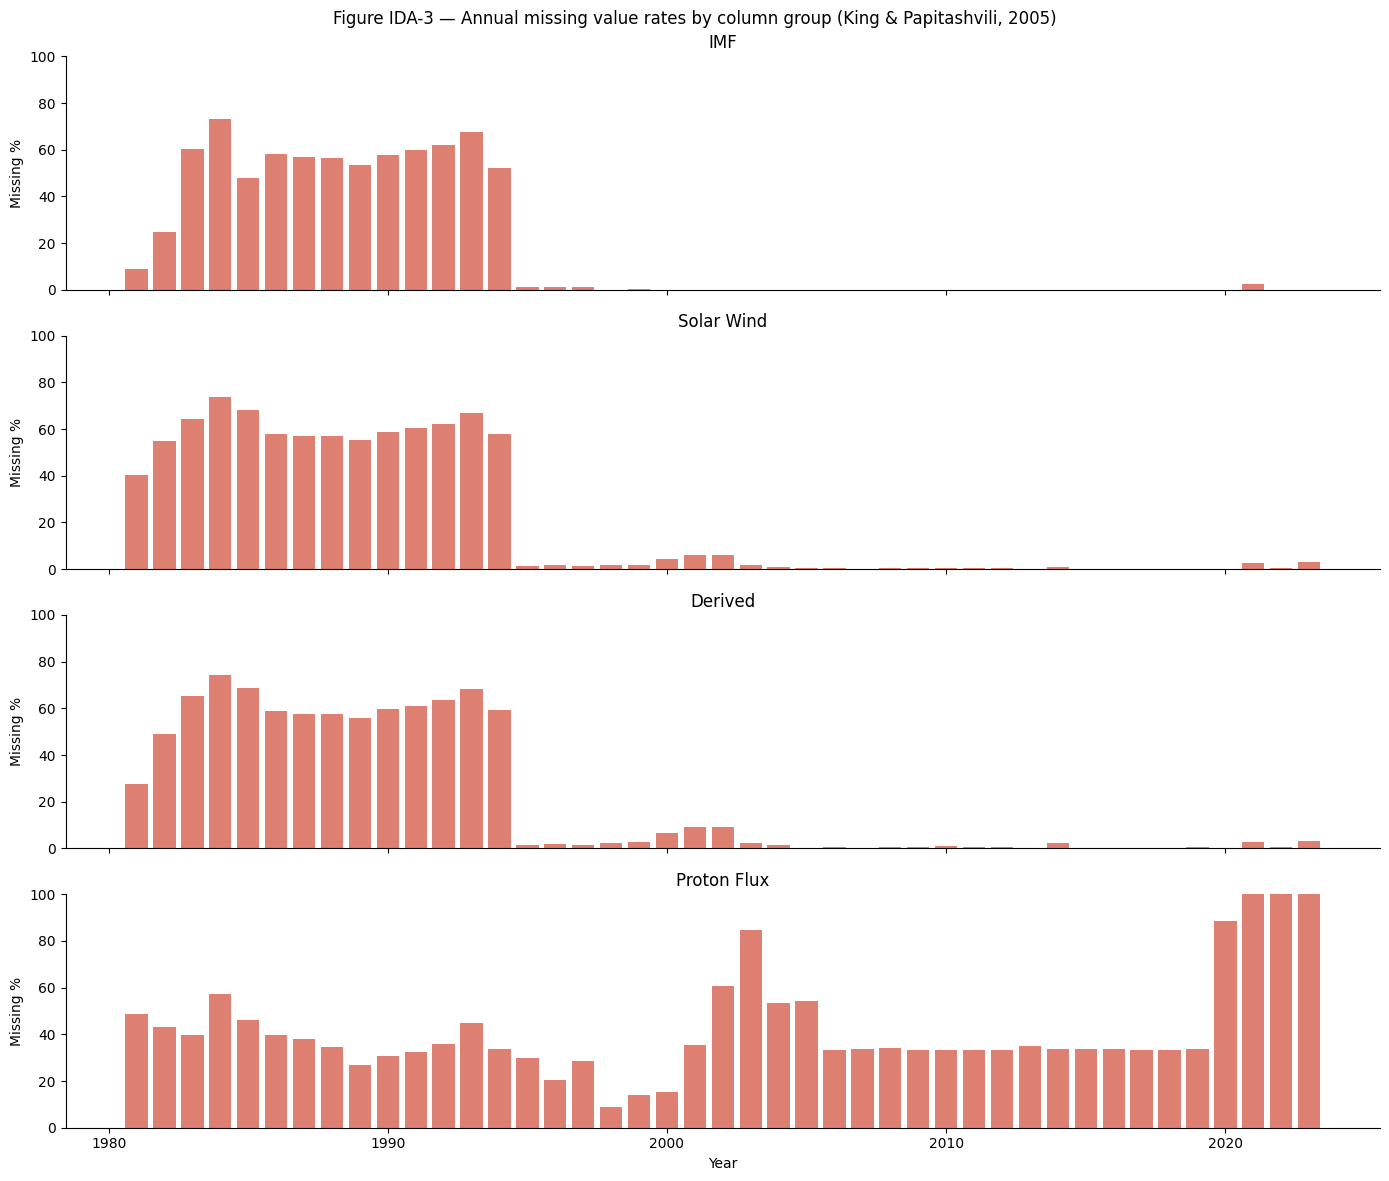

In [9]:

# ── IDA: Annual missing rate per column group ─────────────────────────────────
# df_viz and fill_map defined in setup cell above.
# Representative columns selected per group for clarity.

groups_annual = {
    'IMF':         omni_groups['IMF'][:4],
    'Solar Wind':  omni_groups['Solar Wind Plasma'][:4],
    'Derived':     omni_groups['Derived'][:4],
    'Proton Flux': ['Proton flux (>1 Mev)', 'Proton flux (>10 Mev)', 'Proton flux (>60 Mev)'],
}

fig, axes = plt.subplots(len(groups_annual), 1, figsize=(14, 12), sharex=True)

for ax, (group_name, cols) in zip(axes, groups_annual.items()):
    annual_missing = df_viz.groupby('YEAR')[cols].apply(
        lambda x: x.isnull().mean().mean() * 100
    )
    ax.bar(annual_missing.index, annual_missing, color='#d6604d', alpha=0.8, width=0.8)
    ax.set_ylabel('Missing %')
    ax.set_title(group_name)
    ax.set_ylim(0, 100)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Year')
plt.suptitle('Figure IDA-3 — Annual missing value rates by column group (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida3_missing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


> **Observations — Figure IDA-3:**
- **IMF group:** Missing rates are high (50–75%) throughout 1981–1995, then drop to near zero after 1996 — consistent with the transition to continuous L1 monitoring by the WIND spacecraft. A small spike appears around 2021–2022.
- **Solar Wind group:** Identical pattern to IMF — high missing rates before 1996, near zero after. `Alpha/Prot. ratio` drives the slightly higher overall missing rate due to a known gap after 2018 (Kisvárdai et al., 2024).
- **Derived group:** Mirrors the Solar Wind pattern exactly — derived quantities such as $E_y$, flow pressure, and plasma beta cannot be computed when plasma measurements are missing.
- **Proton Flux group:** A qualitatively different pattern — missing rates are moderate and relatively uniform across 1981–2000, then increase sharply after 2020 reaching 100% in 2022–2023. This is not a spacecraft transition effect but a systematic data gap in recent years (King & Papitashvili, 2005).

The pre-1996 missing data in IMF, Solar Wind, and Derived groups is a known limitation of the early OMNI record and will need to be addressed in Tidy.

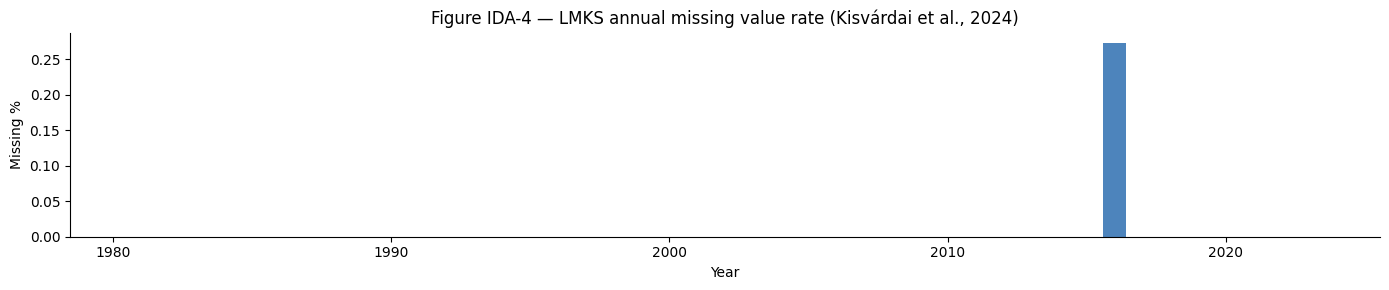

In [10]:

# ── IDA: LMKS annual missing rate ─────────────────────────────────────────────

df_lmks_plot = df_lmks.copy()
df_lmks_plot['YEAR'] = pd.to_datetime(df_lmks_plot['datetime']).dt.year

annual_lmks = df_lmks_plot.groupby('YEAR')['lmks_nm_counts'].apply(
    lambda x: x.isnull().mean() * 100
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(annual_lmks.index, annual_lmks, color='#2166ac', alpha=0.8, width=0.8)
ax.set_ylabel('Missing %')
ax.set_xlabel('Year')
ax.set_title('Figure IDA-4 — LMKS annual missing value rate (Kisvárdai et al., 2024)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig_ida4_lmks_missing.png', dpi=150, bbox_inches='tight')
plt.show()


> **Observations — Figure IDA-4 — LMKS:**  The LMKS neutron count rate is almost entirely complete across the full 1981–2023 record. A single year (~2016) shows a missing rate of ~0.27% — corresponding to the 24 NaN values identified earlier. All other years have 0% missing. This confirms that the LMKS dataset `[KIS24]` is exceptionally clean and requires minimal treatment.

* **Why is data missing?**

The OMNI dataset merges measurements from multiple L1 spacecraft over 42 years. Columns `ID for IMF spacecraft` and `ID for SW Plasma spacecraft` record which spacecraft provided each hourly measurement.

Transitions between spacecraft are a potential source of systematic baseline shifts in the physical measurements.


In [11]:

# ── IDA: Spacecraft ID transitions ───────────────────────────────────────────
# Which spacecraft provided measurements and when transitions occurred.

print("=== IMF spacecraft IDs ===")
print(df_omni['ID for IMF spacecraft'].value_counts().sort_index())

print("\n=== SW Plasma spacecraft IDs ===")
print(df_omni['ID for SW Plasma spacecraft'].value_counts().sort_index())

imf_by_year = df_omni.groupby('YEAR')['ID for IMF spacecraft'].agg(lambda x: x.mode()[0])
sw_by_year  = df_omni.groupby('YEAR')['ID for SW Plasma spacecraft'].agg(lambda x: x.mode()[0])

print("\n=== Dominant IMF spacecraft per year (first 10 years) ===")
print(imf_by_year.head(10).to_string())

print("\n=== Dominant SW spacecraft per year (first 10 years) ===")
print(sw_by_year.head(10).to_string())


=== IMF spacecraft IDs ===
ID for IMF spacecraft
10      1757
13      5605
50     42768
51    204773
60       157
71     45512
99     64660
Name: count, dtype: int64

=== SW Plasma spacecraft IDs ===
ID for SW Plasma spacecraft
13      4572
45      3082
50     39982
51      5104
52    198659
60       217
71     44906
99     68710
Name: count, dtype: int64

=== Dominant IMF spacecraft per year (first 10 years) ===
YEAR
1981    13
1982    13
1983    99
1984    99
1985    99
1986    99
1987    99
1988    99
1989    99
1990    99

=== Dominant SW spacecraft per year (first 10 years) ===
YEAR
1981    13
1982    13
1983    99
1984    99
1985    99
1986    99
1987    99
1988    99
1989    99
1990    99


The results show how many hours each spacecraft was the dominant provider:

- ID `99` — 64,660 IMF hours and 68,710 SW Plasma hours — matches exactly the missing counts from the previous analysis. ID `99` represents the absence of an active L1 mission — this is why data is missing `[KIN05]`.
- ID `51` — 204,773 hours — dominant IMF spacecraft `[PAP20]`.
- ID `52` — 198,659 hours — dominant SW Plasma spacecraft `[PAP20]`.

Spacecraft ID `99` appears 64,660 times in the IMF record and 68,710 times in the SW Plasma record — matching exactly the missing counts observed in the IMF and Solar Wind groups above. When ID is `99`, no spacecraft was providing measurements and all physical columns for that hour carry fill values `[KIN05]`.

To visualise when spacecraft transitions occurred, the dominant spacecraft ID is plotted for each year across the full 1981–2023 record. A change in ID indicates a transition to a different L1 mission.

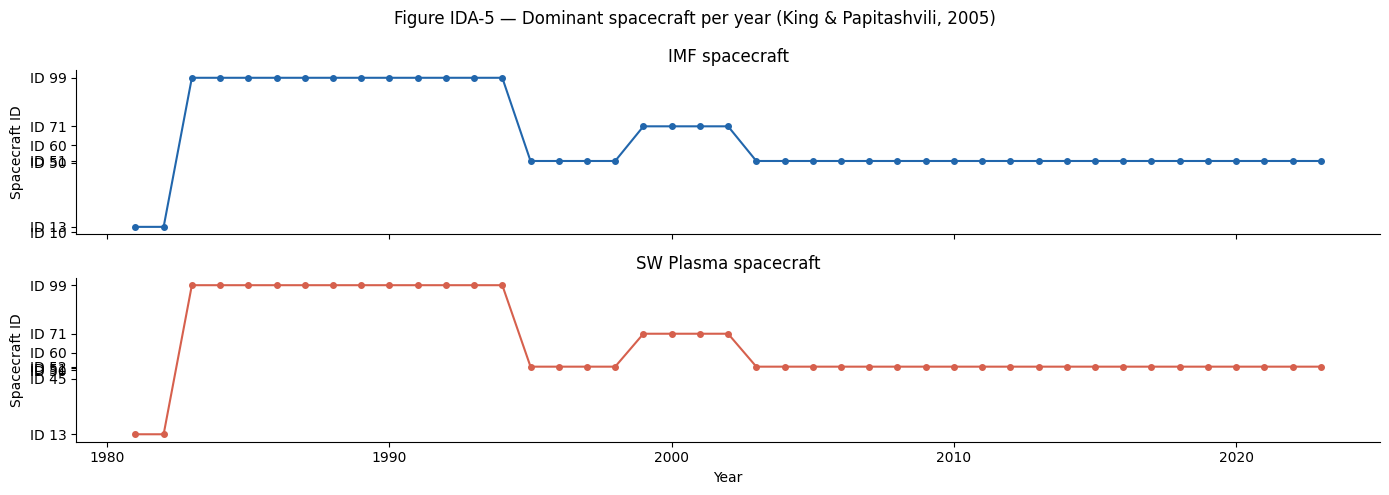

In [12]:

# ── IDA: Dominant spacecraft per year — visualise transitions ────────────────
# For each year, the most frequent spacecraft ID is plotted.
# A step change in ID indicates a transition between L1 missions [PAP20].

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

ax1.plot(imf_by_year.index, imf_by_year.values, 'o-', color='#2166ac', lw=1.5, ms=4)
ax1.set_ylabel('Spacecraft ID')
ax1.set_title('IMF spacecraft')
ax1.set_yticks(sorted(df_omni['ID for IMF spacecraft'].unique()))
ax1.set_yticklabels([f'ID {i}' for i in sorted(df_omni['ID for IMF spacecraft'].unique())])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.plot(sw_by_year.index, sw_by_year.values, 'o-', color='#d6604d', lw=1.5, ms=4)
ax2.set_ylabel('Spacecraft ID')
ax2.set_xlabel('Year')
ax2.set_yticks(sorted(df_omni['ID for SW Plasma spacecraft'].unique()))
ax2.set_yticklabels([f'ID {i}' for i in sorted(df_omni['ID for SW Plasma spacecraft'].unique())])
ax2.set_title('SW Plasma spacecraft')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure IDA-5 — Dominant spacecraft per year (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida5_spacecraft.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations — Figure IDA-5:**

Four distinct periods are visible in both IMF and SW Plasma spacecraft records:

- **1981–1982**: ID 13 (IMP-8) — first two years of the record.
- **1983–1994**: ID 99 — no dominant spacecraft, corresponding exactly to the high missing rates (50–75%) observed in Figure IDA-3.
- **1995–2023**: Continuous L1 coverage — WIND (ID 51/50), ACE (ID 71), and DSCOVR (ID 51/52) with brief overlaps around 1999–2002.
- **2003**: ID 51/52 dominant — ACE and DSCOVR providing stable continuous coverage.

The transition from ID 99 to active spacecraft in 1995 explains the sharp drop in missing rates seen in Figure IDA-3. **The 1983–1994 gap is a structural limitation of the early OMNI record — not a data quality issue but a consequence of no dedicated L1 monitoring mission during that period `[PAP20]`.**

> **Summary — Missing Data**:  The missing data in the OMNI record is not random. Spacecraft ID `99` — indicating no active L1 mission — accounts for all missing hours in the IMF and Solar Wind groups during 1983–1994 `[KIN05]`. After 1995, missing rates drop to near zero across all physical groups. The only systematic exception is `Alpha/Prot. ratio` with a known gap after 2018 (Kisvárdai et al., 2024). The Proton Flux group follows a different pattern — missing rates increase sharply after 2020, reaching 100% in 2022–2023, unrelated to spacecraft transitions `[KIN05]`. The LMKS record is effectively complete with only 24 NaN values across 364,728 rows (Kisvárdai et al., 2024).



#### Data Integrity

Having established when and why data is missing, we now examine the quality of the data that is present. The descriptive statistics revealed two anomalies requiring further investigation: the `Flux FLAG` column takes non-zero values whose meaning is not self-evident from the data alone, and several columns show runs of identical consecutive values that may indicate sensor saturation.


**Flux FLAG**

The `Flux FLAG` column is an integer indicator associated with the energetic proton flux measurements `[KIN05]`. A value of `-1` indicates no proton flux data. Non-zero positive values indicate elevated energetic particle conditions. The distribution of flag values and their temporal pattern are examined below.


The overall distribution of `Flux FLAG` values is examined first, followed by the annual rate of FLAG > 0 to identify whether elevated particle events are concentrated in specific periods.


=== Flux FLAG value counts ===
Flux FLAG
-1    224952
 0    110438
 3       513
 5      3244
 6     26085
Name: count, dtype: int64

Total rows: 365232


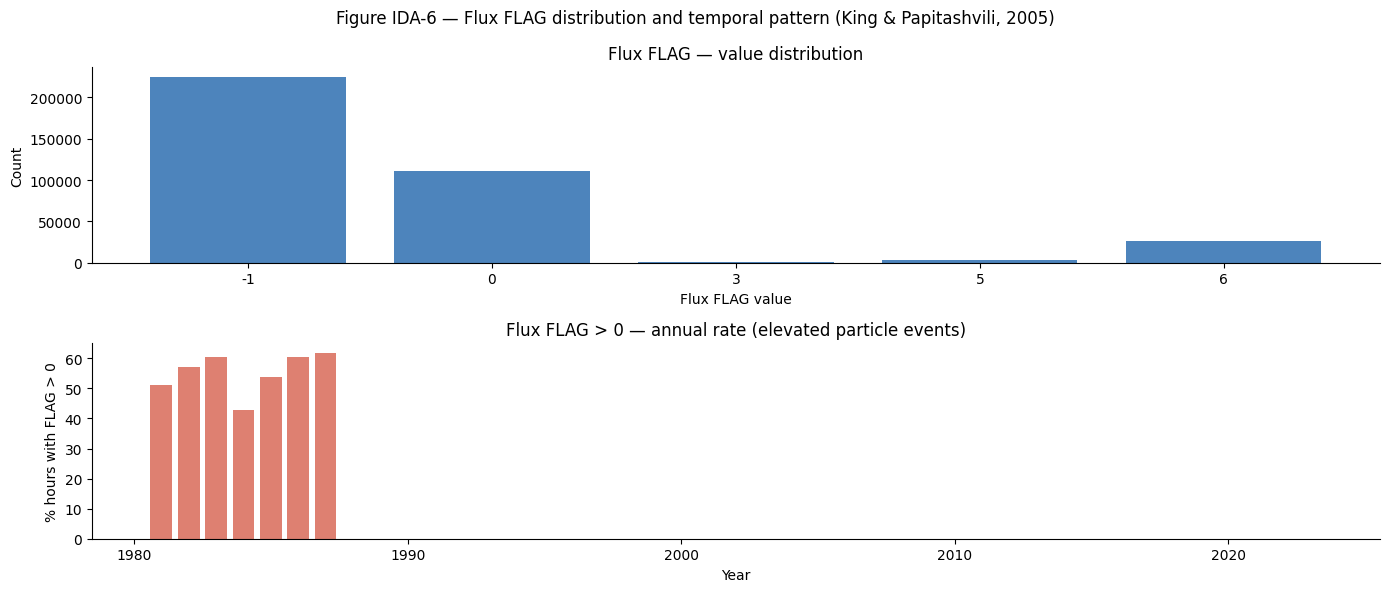

In [13]:

# ── IDA: Flux FLAG — value distribution and annual temporal pattern ───────────
# First: count how many times each flag value appears across the full record.
# Second: compute the annual % of hours where FLAG > 0 (elevated particle events).

print("=== Flux FLAG value counts ===")
print(df_omni['Flux FLAG'].value_counts().sort_index())
print(f"\nTotal rows: {len(df_omni)}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

flag_counts = df_omni['Flux FLAG'].value_counts().sort_index()
ax1.bar(flag_counts.index.astype(str), flag_counts.values, color='#2166ac', alpha=0.8)
ax1.set_xlabel('Flux FLAG value')
ax1.set_ylabel('Count')
ax1.set_title('Flux FLAG — value distribution')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

annual_flag = df_omni.groupby('YEAR')['Flux FLAG'].apply(lambda x: (x > 0).mean() * 100)
ax2.bar(annual_flag.index, annual_flag.values, color='#d6604d', alpha=0.8, width=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('% hours with FLAG > 0')
ax2.set_title('Flux FLAG > 0 — annual rate (elevated particle events)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure IDA-6 — Flux FLAG distribution and temporal pattern (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida6_flux_flag.png', dpi=150, bbox_inches='tight')
plt.show()



`Flux FLAG` takes five distinct values:

- **-1** (224,952 rows — 61.6%): no proton flux data available — consistent with the missing proton flux pattern in Figure IDA-3.
- **0** (110,438 rows — 30.2%): proton flux data present and valid.
- **3** (513 rows — 0.1%): rare flag — meaning not self-evident from the data.
- **5** (3,244 rows — 0.9%): elevated particle conditions.
- **6** (26,085 rows — 7.1%): most common non-zero positive flag — visible in the first 5 rows of the dataset.

The temporal pattern (lower panel) shows that FLAG > 0 occurs exclusively during 1981–1988 — the IMP-8 era. After 1988 no FLAG > 0 values are recorded. This is consistent with the spacecraft transition to ID 99 seen in Figure IDA-5 — during the 1983–1994 gap period, proton flux measurements were either absent or flagged from the IMP-8 era only.

The FLAG column does not serve as a quality filter for the physical parameters of interest ($B_z$, $V_{sw}$, $D_{st}$) — it pertains exclusively to the proton flux measurements.


* **Sensor Saturation**

During extreme geomagnetic storms, physical sensors can reach their measurement limits and report the same value for consecutive hours — a phenomenon known as sensor saturation `[KIS25]`. Consecutive identical values are checked in the key physical columns, particularly `Dst-index, nT` and `BZ, nT (GSM)`.



For each key column, fill values are excluded and the length of consecutive identical value runs is computed. The distribution of run lengths reveals whether sensors report the same value for implausibly long periods.


=== Top 10 longest runs — SW Proton Density ===
                           value  length   start
SW Proton Density, N/cm^3                       
183947                       0.4      21  194688
290571                       0.3      11  313600
166690                       0.8      11  175201
206610                       0.5      11  220178
333033                       0.2      11  359986
239752                       0.7      10  257198
170607                       0.1      10  179511
148021                       0.5       9  154094
150851                       1.0       9  157319
193657                       0.5       9  205626


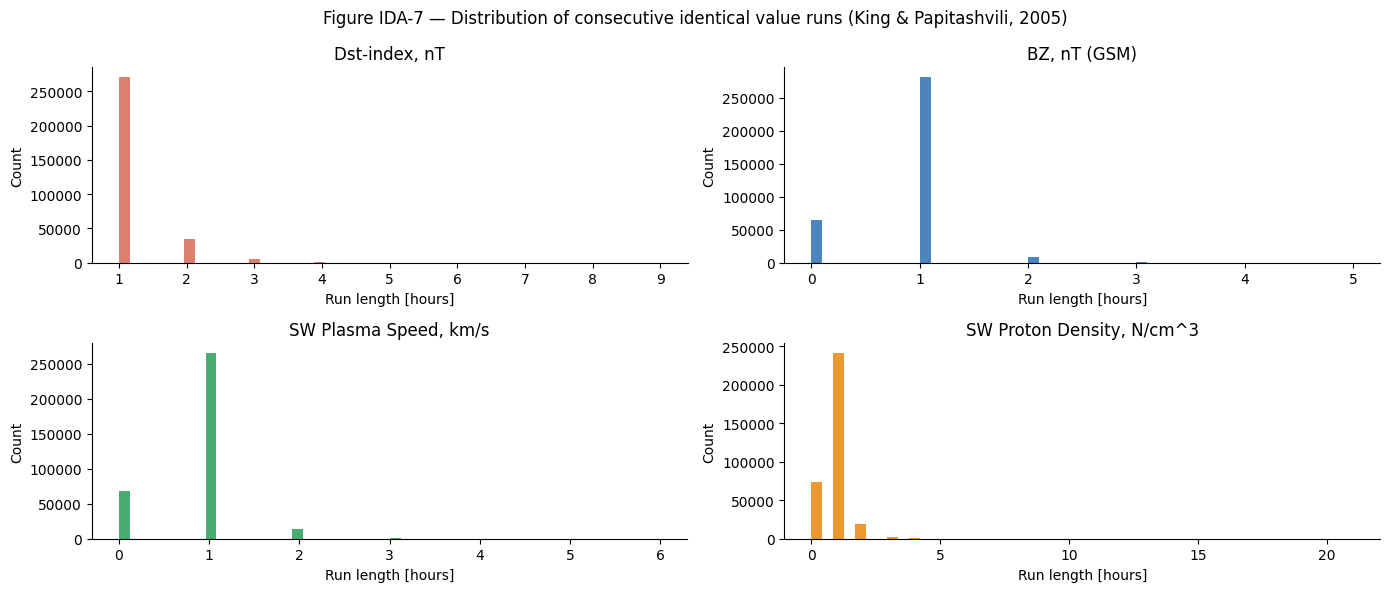

In [14]:

# ── IDA: Sensor saturation — run length distribution per key column ───────────
# Fill values are excluded before computing runs.
# A right-skewed distribution with most runs of length 1 indicates no saturation.

def find_runs(series, fill_val=None):
    """Returns DataFrame with start index, value, and length of each run."""
    s = series.copy()
    if fill_val is not None:
        s = s.replace(fill_val, np.nan)
    run_id = (s != s.shift()).cumsum()
    runs = s.groupby(run_id).agg(['first', 'count'])
    runs.columns = ['value', 'length']
    runs['start'] = s.groupby(run_id).apply(lambda x: x.index[0])
    return runs.sort_values('length', ascending=False).head(10)

print("=== Top 10 longest runs — SW Proton Density ===")
print(find_runs(df_omni['SW Proton Density, N/cm^3'],
                fill_val=fill_map['SW Proton Density, N/cm^3']))

cols_plot = [
    ('Dst-index, nT',             '#d6604d'),
    ('BZ, nT (GSM)',              '#2166ac'),
    ('SW Plasma Speed, km/s',     '#1a9850'),
    ('SW Proton Density, N/cm^3', '#e67e00'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for ax, (col, color) in zip(axes.flatten(), cols_plot):
    fv = fill_map.get(col)
    s  = df_omni[col].replace(fv, np.nan) if fv is not None else df_omni[col]
    run_id     = (s != s.shift()).cumsum()
    run_lengths = s.groupby(run_id).count()
    ax.hist(run_lengths, bins=50, color=color, alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Run length [hours]')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Figure IDA-7 — Distribution of consecutive identical value runs (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida7_saturation.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations — Figure IDA-7:**

No systematic sensor saturation is detected. All four columns show strongly right-skewed run length distributions — the vast majority of runs have length 1, which is expected for physical time series.

- `Dst-index, nT`: runs rarely exceed 3 hours. The integer nature of $D_{st}$ means short runs of identical values are physically plausible during quiet conditions.
- `BZ, nT (GSM)`: almost all runs are length 1. No evidence of saturation.
- `SW Plasma Speed, km/s`: runs rarely exceed 2 hours. No evidence of saturation.
- `SW Proton Density, N/cm^3`: the distribution has a longer tail extending to 21 hours. The longest run is value `0.4 N/cm³` for 21 consecutive hours — physically very low for solar wind proton density where typical values are `5`–`10 N/cm³`. This is the only notable anomaly and may reflect either a real solar wind rarefaction event or a measurement artifact.

No systematic sensor saturation detected. The `SW Proton Density` tail is the only notable anomaly and may reflect either a real solar wind rarefaction event or a measurement artifact.


* **Summary — Data Integrity**

Two potential data quality issues are examined. The `Flux FLAG` column takes non-zero positive values exclusively during 1981–1988 and pertains only to proton flux measurements — it does not affect $B_z$, $V_{sw}$, or $D_{st}$. Run length analysis (Figure IDA-7) shows no systematic sensor saturation in `Dst-index, nT`, `BZ, nT (GSM)`, or `SW Plasma Speed` — all distributions are strongly right-skewed with the vast majority of runs at length 1. The only notable anomaly is identified in `SW Proton Density`: a run of 21 consecutive hours reporting $0.4\ \text{N/cm}^3$ starting at row index 194,688 — a value far below the typical solar wind range of $5$–$10\ \text{N/cm}^3$. The physical origin of this run is ambiguous — it may represent a real solar wind rarefaction event or a measurement artifact.


* **Summary — Data Quality**

The OMNI record has two structurally distinct missing data problems. The first is the 1983–1994 gap — caused by the absence of a dedicated L1 mission — affecting all IMF, Solar Wind, and Derived columns uniformly. The second is the Proton Flux group where `>1`, `>2`, `>4` MeV channels are missing 64.1% of the record, increasing to 100% after 2020. The `Alpha/Prot. ratio` has a systematic gap after 2018 (Kisvárdai et al., 2024). The geomagnetic indices — including the target variable `Dst-index, nT` — have no missing values. The LMKS record is effectively complete.

Based on these observations, the following columns are flagged as problematic candidates:

- `Proton flux (>1 Mev)`, `Proton flux (>2 Mev)`, `Proton flux (>4 Mev)` — 64.1% missing
- `Alpha/Prot. ratio` — 28.7% missing with a systematic post-2018 gap
- All sigma columns — documented as data quality indicators, not physical measurements `[KIN05]`



### Feature-Target Analysis

Having examined data completeness and quality, the relationships between variables are explored. The target variable $D_{st}$ is examined against all physical column groups to identify which measurements carry the most predictive information.



For each physical group, a representative subset of columns is selected for the correlation analysis. The selection is motivated by the domain: in the IMF group, the GSM coordinate system is physically more relevant for geomagnetic storms as it is aligned with Earth's magnetic field, making $B_z$ (GSM) the primary variable in the Burton injection function `[BUR75]`; GSE components are included for comparison. In the Solar Wind Plasma group, the four bulk plasma parameters are selected; flow angles are excluded as they have near-zero correlation with $D_{st}$ (established above). In the Derived group, $E_y$ is the direct Burton driver, while Plasma Beta and Alfvén mach number are included as they share physical dependencies. In the Geomagnetic Indices group, $D_{st}$ is the target variable and is included to reveal its linear relationships with the other indices.



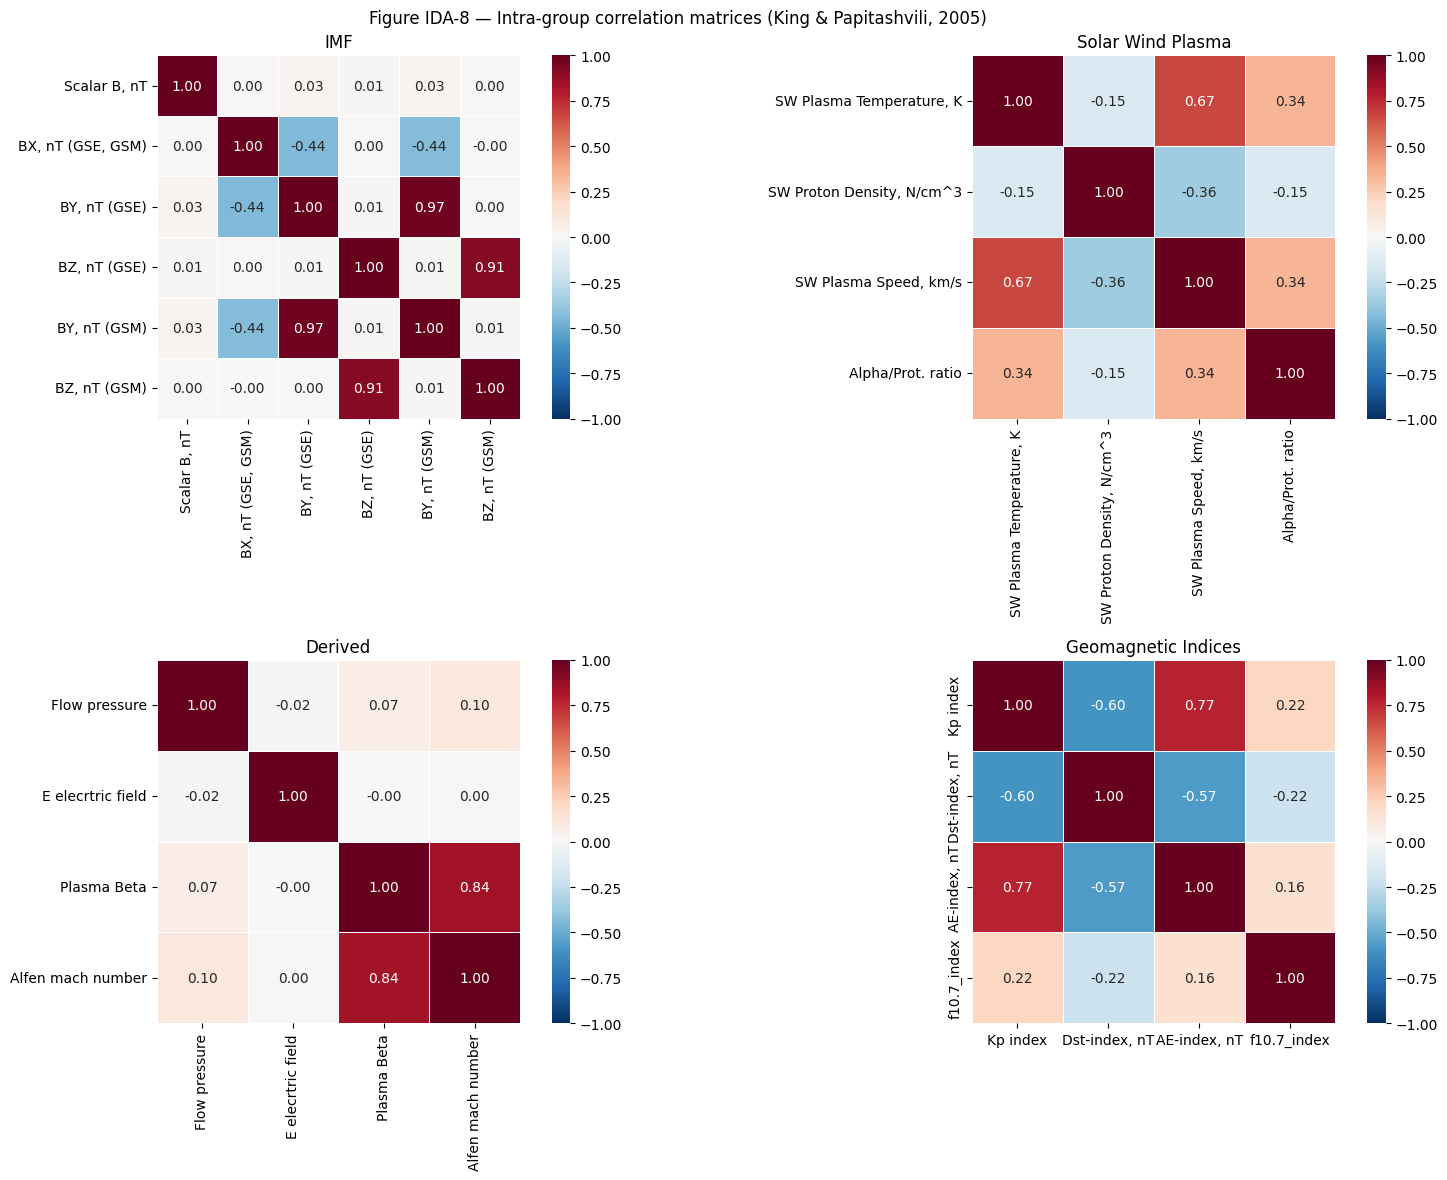

In [15]:

# ── IDA: Intra-group correlation matrix ───────────────────────────────────────
# df_corr defined in setup cell above — fill values replaced with NaN.
# Columns selected per group based on physical relevance to geomagnetic storms.
# Selection motivated by the Burton (1975) model [BUR75] and domain knowledge.

groups_corr = {
    'IMF': [
        'Scalar B, nT',
        'BX, nT (GSE, GSM)',
        'BY, nT (GSE)', 'BZ, nT (GSE)',
        'BY, nT (GSM)', 'BZ, nT (GSM)',
    ],
    'Solar Wind Plasma': [
        'SW Plasma Temperature, K',
        'SW Proton Density, N/cm^3',
        'SW Plasma Speed, km/s',
        'Alpha/Prot. ratio',
    ],
    'Derived': [
        'Flow pressure',
        'E elecrtric field',
        'Plasma Beta',
        'Alfen mach number',
    ],
    'Geomagnetic Indices': [
        'Kp index',
        'Dst-index, nT',
        'AE-index, nT',
        'f10.7_index',
    ],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (group_name, cols) in zip(axes.flatten(), groups_corr.items()):
    corr_matrix = df_corr[cols].corr()
    sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5)
    ax.set_title(group_name)

plt.suptitle('Figure IDA-8 — Intra-group correlation matrices (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida8_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations — Figure IDA-8:**

**IMF group:** `BY, nT (GSE)` and `BY, nT (GSM)` are highly correlated ($r = 0.97$), as are `BZ, nT (GSE)` and `BZ, nT (GSM)` ($r = 0.91$) — the GSE and GSM coordinate representations carry nearly identical information. `BX` shows a moderate negative correlation with both `BY` components ($r = -0.44$). `Scalar B` is uncorrelated with the directional components.

**Solar Wind Plasma group:** `SW Plasma Temperature` and `SW Plasma Speed` show a moderate positive correlation ($r = 0.67$) — faster solar wind tends to be hotter, consistent with known solar wind physics. `SW Proton Density` is weakly negatively correlated with speed ($r = -0.36$). `Alpha/Prot. ratio` shows weak correlations across the group.

**Derived group:** `Plasma Beta` and `Alfvén mach number` are strongly correlated ($r = 0.84$) — both depend on similar combinations of plasma and magnetic field parameters. `Flow pressure` and `E electric field` are effectively independent of each other and of the other derived quantities.

**Geomagnetic Indices group:** `Kp index` and `AE-index` are strongly correlated ($r = 0.77$). `Kp index` and `Dst-index, nT` show a moderate negative correlation ($r = -0.60$). `f10.7_index` shows weak correlations with all other indices ($r \leq 0.22$).

Three pairs of columns carry near-duplicate information: `BY` GSE/GSM ($r = 0.97$), `BZ` GSE/GSM ($r = 0.91$), and `Plasma Beta`/`Alfvén mach` ($r = 0.84$) — retaining one representative from each pair reduces redundancy without losing physical information. `Kp index` and `AE-index` are correlated with `Dst-index, nT` but measure distinct aspects of geomagnetic activity — their use as predictors carries a data leakage risk since all three are recorded at the same hourly timestamp as the target variable.


The target variable `Dst-index, nT` measures the intensity of geomagnetic storms. To understand which physical measurements carry information about it, the linear relationship between each column group and `Dst-index, nT` is examined. This gives a first quantitative picture of the data structure — which groups are most strongly associated with the target, and which are weakly or not linearly related. To keep the comparison manageable, one representative is selected from each group based on the highest absolute Pearson correlation with `Dst-index, nT`.



In [16]:
# ── IDA: Pearson correlation of each column with Dst-index, nT ───────────────
# df_corr defined in setup cell above — fill values replaced with NaN, LMKS aligned.
# Group leader = column with highest |r| vs Dst within each group.

dst = df_corr['Dst-index, nT']

leaders = {}
print(f"{'Group':<25} {'Column':<35} {'r':>8}")
print("-" * 72)

for group_name, cols in omni_groups.items():
    if group_name in ('Time', 'Administrative'):
        continue
    best_col = None
    best_r   = 0
    for col in cols:
        if col not in df_corr.columns or col == 'Dst-index, nT':
            continue
        valid = df_corr[col].notna() & dst.notna()
        if valid.sum() >= 1000:
            r = df_corr.loc[valid, col].corr(dst.loc[valid])
            print(f"  {group_name:<23} {col:<35} {r:>8.3f}")
            if abs(r) > abs(best_r):
                best_r   = r
                best_col = col
    leaders[group_name] = (best_col, best_r)
    print()

# LMKS
col   = 'lmks_nm_counts'
valid = df_corr[col].notna() & dst.notna()
r     = df_corr.loc[valid, col].corr(dst.loc[valid])
print(f"  {'LMKS':<23} {col:<35} {r:>8.3f}")
leaders['LMKS'] = (col, r)

print("\n=== Group leaders ===")
for group_name, (col, r) in leaders.items():
    print(f"  {group_name:<25} {col:<35} r = {r:.3f}")


Group                     Column                                     r
------------------------------------------------------------------------
  IMF                     Scalar B, nT                          -0.352
  IMF                     Vector B Magnitude,nT                 -0.338
  IMF                     Lat. Angle of B (GSE)                  0.174
  IMF                     Long. Angle of B (GSE)                -0.004
  IMF                     BX, nT (GSE, GSM)                     -0.007
  IMF                     BY, nT (GSE)                          -0.008
  IMF                     BZ, nT (GSE)                           0.234
  IMF                     BY, nT (GSM)                          -0.007
  IMF                     BZ, nT (GSM)                           0.301
  IMF                     RMS_magnitude, nT                     -0.050
  IMF                     RMS_field_vector, nT                  -0.178
  IMF                     RMS_BX_GSE, nT                        -0.144
  IM

**Observations — correlation with $D_{st}$:**

**IMF group:** `Scalar B, nT` leads with $r = -0.352$. `BZ, nT (GSM)` shows $r = 0.301$ — lower than expected from the Burton equation `[BUR75]`, consistent with its non-linear threshold behaviour: only sustained negative $B_z$ drives storms. The directional components `BX` and `BY` show near-zero linear correlation with $D_{st}$.

**Solar Wind Plasma group:** `SW Plasma Speed` leads with $r = -0.469$ — faster solar wind tends to produce stronger storms.

**Sigma group:** `sigma-V` leads with $r = -0.265$. These are data quality indicators `[KIN05]`, not physical drivers — their correlation with $D_{st}$ likely reflects increased solar wind variability during active periods.

**Derived group:** `E electric field` leads with $r = -0.293$ — the Burton injection driver. The modest linear correlation is consistent with the threshold nature of $Q(E_y)$ `[BUR75]`.

**Solar Activity group:** `f10.7_index` leads with $r = -0.216$, followed by `R (Sunspot No.)` ($r = -0.203$) and `Lyman_alpha` ($r = -0.201$). All three show weak correlations — consistent with their role as background solar activity proxies rather than direct storm drivers.

**Geomagnetic Indices group:** `ap_index, nT` leads with $r = -0.644$, followed by `Kp index` ($r = -0.601$). Both measure geomagnetic activity alongside $D_{st}$ — this high correlation is expected. `AL-index` shows $r = +0.571$ — positive because AL measures the negative auroral electrojet.

**Proton Flux group:** All channels show $|r| < 0.13$. Given 64.1% missing data, the linear correlation estimate is unreliable for this group.

**LMKS:** `lmks_nm_counts` shows $r = +0.289$ — positive because higher cosmic ray flux corresponds to quieter geomagnetic conditions, consistent with Kisvárdai et al. (2025) `[KIS25]`.

> Note: Pearson correlation captures only linear relationships. A low $|r|$ does not preclude a column from carrying predictive information through non-linear interactions or threshold effects.


The following columns are selected for scatter plot analysis based on their physical relevance to the domain and the observations from the correlation analysis above:

- `BZ, nT (GSM)` — the primary driver of geomagnetic storms in the Burton equation `[BUR75]`
- `SW Plasma Speed, km/s` — strongest linear predictor in the Solar Wind group
- `E electric field` — the direct injection driver in the Burton model `[BUR75]`
- `ap_index, nT` — strongest linear predictor overall; included to visualise its relationship with $D_{st}$, noting that both indices respond to the same geomagnetic disturbance and its use as a predictor carries a data leakage risk
- `lmks_nm_counts` — the cosmic ray precursor signal `[KIS25]`


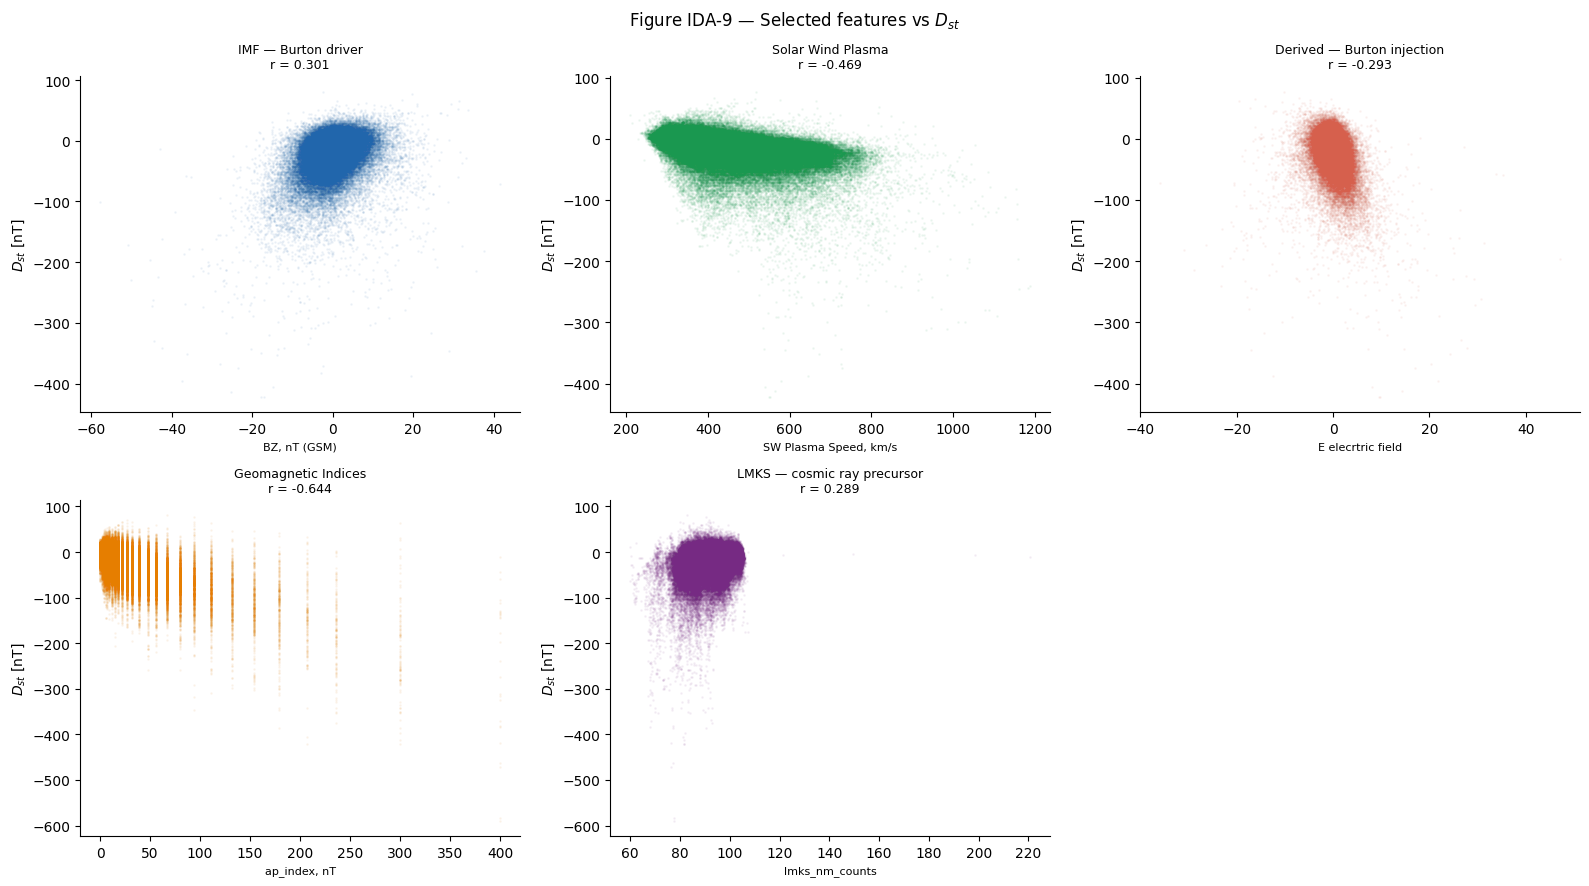

In [17]:
# ── IDA: Scatter plots — physically motivated feature selection vs Dst ────────
# Selection is based on domain knowledge and correlation analysis above.
# Fill values are already replaced with NaN in df_corr.

leaders_plot = [
    ('BZ, nT (GSM)',          'IMF — Burton driver',         '#2166ac'),
    ('SW Plasma Speed, km/s', 'Solar Wind Plasma',           '#1a9850'),
    ('E elecrtric field',     'Derived — Burton injection',  '#d6604d'),
    ('ap_index, nT',          'Geomagnetic Indices',         '#e67e00'),
    ('lmks_nm_counts',        'LMKS — cosmic ray precursor', '#762a83'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, group, color) in zip(axes, leaders_plot):
    x     = df_corr[col]
    y     = dst
    valid = x.notna() & y.notna()
    ax.scatter(x[valid], y[valid], alpha=0.05, s=1, color=color)
    r = x[valid].corr(y[valid])
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('$D_{st}$ [nT]')
    ax.set_title(f'{group}\nr = {r:.3f}', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_visible(False)
plt.suptitle('Figure IDA-9 — Selected features vs $D_{st}$', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida9_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations — Figure IDA-9:**

**BZ, nT (GSM)** ($r = 0.301$): The relationship is asymmetric — negative $B_z$ (southward field) is associated with strongly negative $D_{st}$, while positive $B_z$ shows no systematic effect. This confirms the threshold behaviour in the Burton injection function `[BUR75]`: only southward $B_z$ drives storms. The cloud is heavily concentrated near zero — consistent with the dominance of quiet conditions.

**SW Plasma Speed** ($r = -0.469$): A clear elongated pattern — higher speeds are associated with more negative $D_{st}$. The relationship appears approximately linear for speeds above $500\ \text{km/s}$, with the most extreme storms occurring at the highest speeds.

**E electric field** ($r = -0.293$): The distribution is strongly concentrated near zero — consistent with the threshold at $E_y = 0.5\ \text{mV/m}$ in the Burton model `[BUR75]`. Extreme negative $D_{st}$ values appear only when $E_y$ is large and negative.

**ap_index** ($r = -0.644$): The vertical striping pattern reveals that `ap_index` is a discrete integer variable. The strong correlation is expected — both `ap` and $D_{st}$ respond to the same geomagnetic disturbances. This column cannot serve as a predictor of $D_{st}$ without introducing circular reasoning.

**lmks_nm_counts** ($r = 0.289$): The bulk of the data clusters in a narrow count rate range ($80$–$105\ \text{counts/min}$). Extreme negative $D_{st}$ values occur across a wide range of neutron counts — the relationship is diffuse, consistent with the modest $\text{PPS} = 0.22$ reported by Kisvárdai et al. (2025) `[KIS25]`.


The five scatter plots tell a coherent physical story. `BZ, nT (GSM)` and `E electric field` reveal that geomagnetic storms are not random — they occur only when the interplanetary magnetic field is directed southward. At positive $B_z$ values, no strong storms appear anywhere in the 42-year record. This is the physical threshold described by the Burton injection function `[BUR75]`: the southward $B_z$ is the gate that must be open for a storm to develop. `SW Plasma Speed` shows that once the gate is open, speed determines storm intensity. Slow solar wind produces weak storms; the most extreme $D_{st}$ values appear exclusively at high speeds above $600\ \text{km/s}$. `ap_index` reacts simultaneously with $D_{st}$ to the same geomagnetic disturbance — the vertical striping pattern confirms it is a discrete variable that responds to the same event it would be used to predict. It cannot serve as a predictor without introducing circular reasoning. `lmks_nm_counts` tells a different story from the others. The bulk of the data clusters in a narrow count rate range with no clear linear structure. However, the most extreme storms appear preferentially at lower neutron counts — consistent with the Forbush Decrease precursor signal described by Kisvárdai et al. (2025) `[KIS25]`. The signal is present but diffuse, consistent with the modest $\text{PPS} = 0.22$ reported in the same study.



### Temporal Structure

The dataset spans 42 years and four solar cycles. Before combining the two sources and building features, it is necessary to establish whether the measurements are stationary — whether their statistical properties remain consistent across the full record, or whether they shift systematically between periods. Baseline shifts and non-stationarity affect how the data can be split and how missing values should be treated.


The full time series of the key physical variables is plotted to identify long-term trends, baseline shifts, and solar cycle modulation. The hourly time series of four key variables is plotted across the full 1981–2023 record. A 27-day rolling mean is overlaid — corresponding to one Carrington solar rotation period — to smooth short-term variability and reveal longer-term trends and solar cycle modulation.



To quantify the non-stationarity suggested by the time series, the mean and standard deviation of key variables are computed for each solar cycle period.


In [18]:
# ── IDA: Mean and std of key variables per solar cycle period ─────────────────
# Solar cycle boundaries follow the split defined in Methods.
# df_viz used — fill values replaced with NaN.

df_viz['cycle'] = pd.cut(
    df_viz['YEAR'],
    bins=[1980, 1996, 2008, 2024],
    labels=['Cycles 21+22 (1981–1996)', 'Cycle 23 (1996–2008)', 'Cycles 24+25 (2008–2023)']
)

cols_stat = [
    'BZ, nT (GSM)',
    'SW Plasma Speed, km/s',
    'E elecrtric field',
    'Dst-index, nT',
]

for col in cols_stat:
    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")
    print(df_viz.groupby('cycle', observed=True)[col].agg(['mean', 'std', 'min', 'max']).round(2).to_string())



────────────────────────────────────────────────────────────
  BZ, nT (GSM)
────────────────────────────────────────────────────────────
                          mean   std   min   max
cycle                                           
Cycles 21+22 (1981–1996)  0.07  3.39 -32.3  31.0
Cycle 23 (1996–2008)     -0.04  3.25 -57.8  41.6
Cycles 24+25 (2008–2023) -0.05  2.73 -32.4  33.7

────────────────────────────────────────────────────────────
  SW Plasma Speed, km/s
────────────────────────────────────────────────────────────
                            mean     std    min     max
cycle                                                  
Cycles 21+22 (1981–1996)  448.61  106.02  209.0  1090.0
Cycle 23 (1996–2008)      444.30  108.10  228.0  1189.0
Cycles 24+25 (2008–2023)  412.73   90.81  233.0   878.0

────────────────────────────────────────────────────────────
  E elecrtric field
────────────────────────────────────────────────────────────
                          mean   std    min    

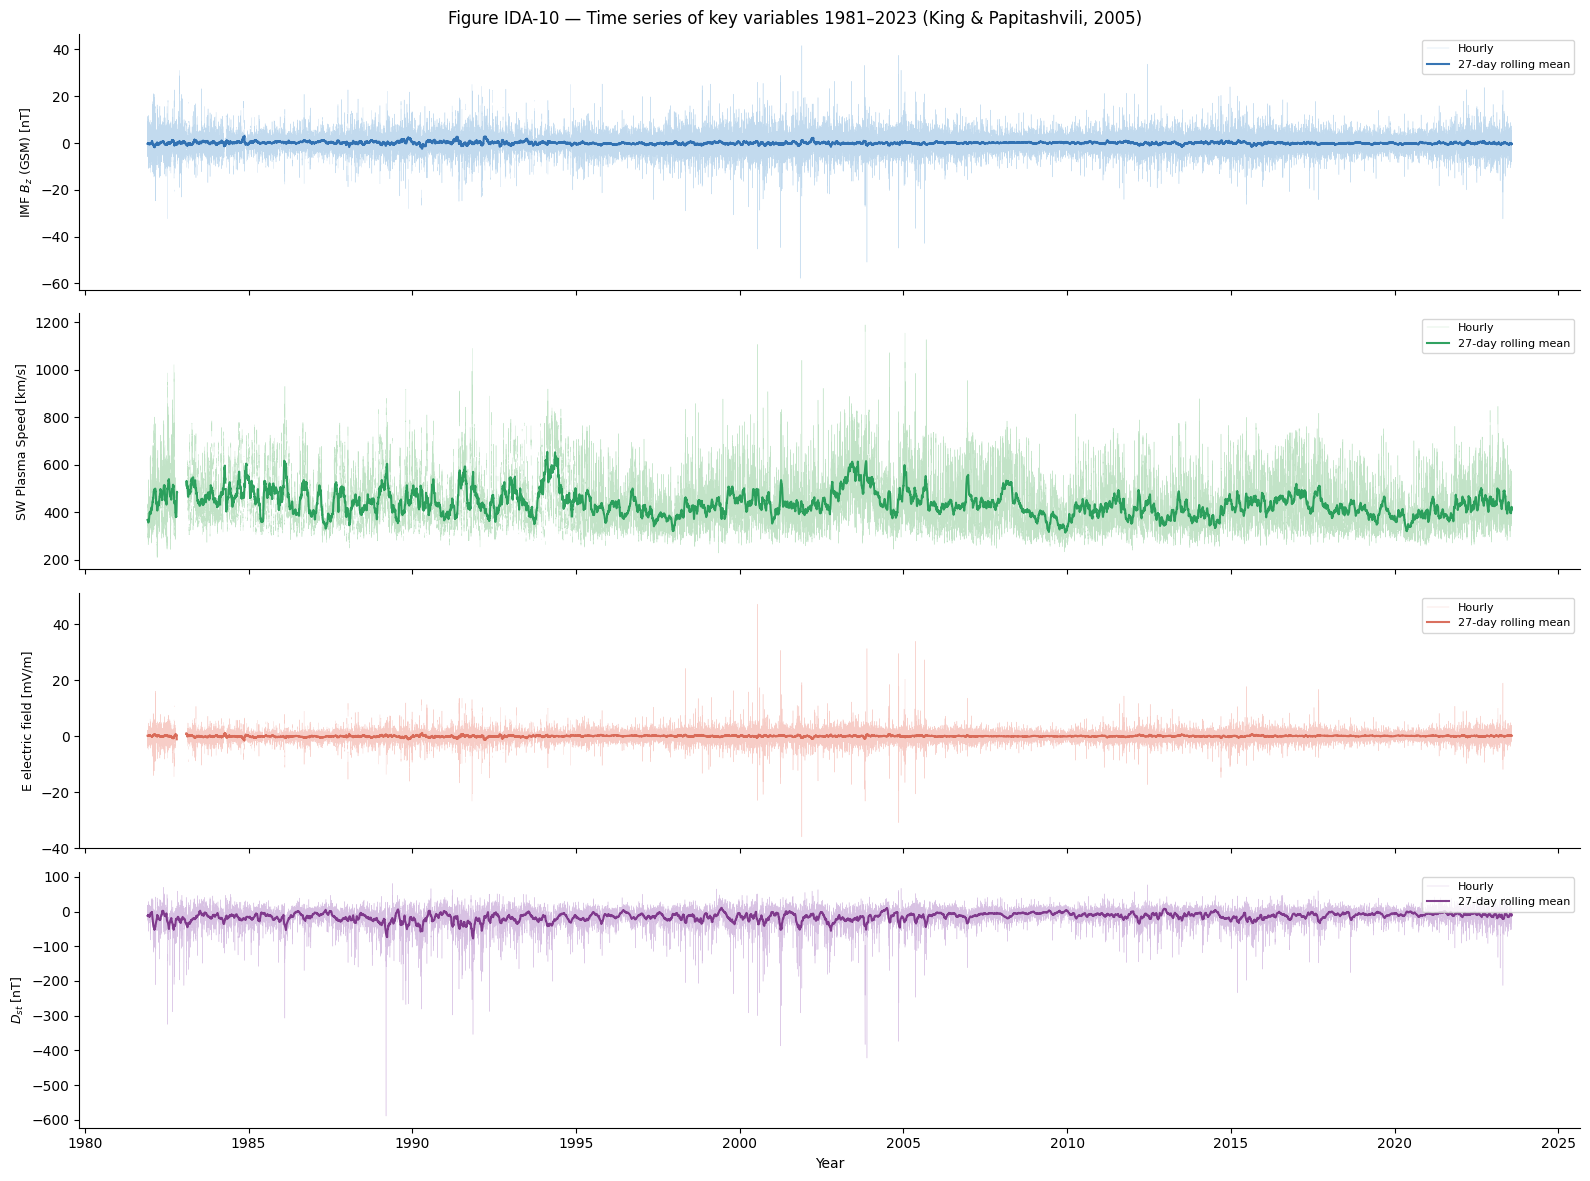

In [19]:
# ── IDA: Time series of key variables across the full record ─────────────────
# df_viz defined in setup cell above — fill values replaced with NaN.
# The 27-day rolling mean (one Carrington rotation) highlights solar cycle modulation.

cols_ts = [
    ('BZ, nT (GSM)',          '#a8cbe8', '#2166ac', 'IMF $B_z$ (GSM) [nT]'),
    ('SW Plasma Speed, km/s', '#a8d8b0', '#1a9850', 'SW Plasma Speed [km/s]'),
    ('E elecrtric field',     '#f4b8b0', '#d6604d', 'E electric field [mV/m]'),
    ('Dst-index, nT',         '#c8a8d8', '#762a83', '$D_{st}$ [nT]'),
]

fig, axes = plt.subplots(len(cols_ts), 1, figsize=(16, 12), sharex=True)

for ax, (col, color_raw, color_roll, label) in zip(axes, cols_ts):
    ax.plot(df_viz['datetime'], df_viz[col],
            color=color_raw, lw=0.3, alpha=0.7, label='Hourly')
    rolling = df_viz[col].rolling(window=27*24, center=True, min_periods=24).mean()
    ax.plot(df_viz['datetime'], rolling,
            color=color_roll, lw=1.5, alpha=0.9, label='27-day rolling mean')
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Year')
plt.suptitle('Figure IDA-10 — Time series of key variables 1981–2023 (King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida10_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()



**Observations — Figure IDA-10 and cycle statistics:**

**IMF $B_z$ (GSM):** The 27-day rolling mean stays near zero across the full record. The cycle statistics confirm this — mean values of $0.07$, $-0.04$, and $-0.05\ \text{nT}$ across the three periods. No baseline shift or long-term trend is present. The standard deviation decreases slightly in cycles 24+25 ($2.73\ \text{nT}$ vs $3.39\ \text{nT}$), suggesting marginally lower IMF variability in the weaker cycles.

**SW Plasma Speed:** The rolling mean shows visible variation across the record — elevated during solar maxima and lower after 2010. The cycle statistics confirm this: mean speed decreases from $448.6\ \text{km/s}$ in cycles 21+22 to $412.7\ \text{km/s}$ in cycles 24+25, and the maximum drops from $1{,}189\ \text{km/s}$ to $878\ \text{km/s}$.

**E electric field:** The rolling mean is near zero throughout — indistinguishable at this scale. The cycle statistics confirm no baseline shift, but the standard deviation decreases from $1.58\ \text{mV/m}$ in cycle 23 to $1.17\ \text{mV/m}$ in cycles 24+25, consistent with the lower $V_{sw}$ variability.

**$D_{st}$:** The rolling mean is visibly more negative before 2010 and quieter after. The cycle statistics quantify this: mean $D_{st}$ goes from $-19.2\ \text{nT}$ in cycles 21+22 to $-10.1\ \text{nT}$ in cycles 24+25. The minimum storm intensity drops from $-589\ \text{nT}$ to $-234\ \text{nT}$. The record is non-stationary — storm activity systematically decreases across the 42-year period, consistent with the weaker recent solar cycles visible in Figure 4.


### Anomalies

The two datasets span 42 years and cover periods of both quiet and extreme solar activity. Anomalous values — measurements that deviate significantly from the typical range — are identified and characterised in both records. The LMKS record was examined in the previous section where GLE events and Forbush Decreases were identified (Figure IDA-8). Kisvárdai et al. (2025) `[KIS25]` specifically document the GLE of 29 September 1989 as the largest event recorded at LMKS. Here the extreme values in the $D_{st}$ record are examined.


The most extreme $D_{st}$ values in the record are identified by sorting the hourly observations.

In [20]:
# ── IDA: Extreme Dst events — identify the most negative hourly values ────────
# Fill values are already replaced with NaN in df_viz.
# The datetime column is used to associate each extreme value with a date.

dst_series = df_viz[['datetime', 'Dst-index, nT']].dropna()
dst_series = dst_series.sort_values('Dst-index, nT').head(20)

print("=== Top 20 most negative Dst values ===")
print(dst_series.to_string(index=False))


=== Top 20 most negative Dst values ===
           datetime  Dst-index, nT
1989-03-14 01:00:00           -589
1989-03-14 00:00:00           -583
1989-03-13 23:00:00           -472
1989-03-14 02:00:00           -463
2003-11-20 21:00:00           -422
2003-11-20 20:00:00           -422
1989-03-13 22:00:00           -418
2003-11-20 19:00:00           -413
2003-11-20 22:00:00           -405
2003-11-20 18:00:00           -396
2001-03-31 08:00:00           -387
1989-03-14 03:00:00           -386
2003-10-30 22:00:00           -383
1989-03-13 21:00:00           -382
2004-11-08 06:00:00           -374
2003-10-30 23:00:00           -371
2004-11-08 05:00:00           -368
1991-11-09 01:00:00           -354
2003-10-30 00:00:00           -353
2001-03-31 07:00:00           -351


**Observations — extreme $D_{st}$ events:**

The 20 most negative hourly $D_{st}$ values cluster around four distinct storm events:

- **March 1989** — the most intense storm in the record, reaching $D_{st} = -589\ \text{nT}$ on 14 March 1989. Eight of the top 20 values belong to this event.
- **November 2003** — the Halloween storm of 20 November 2003, reaching $D_{st} = -422\ \text{nT}$. Six of the top 20 values belong to this event.
- **October 2003** — a separate Halloween storm on 30 October 2003, reaching $D_{st} = -383\ \text{nT}$.
- **March 2001** and **November 2004** — two additional extreme events reaching $D_{st} \approx -387\ \text{nT}$ and $-374\ \text{nT}$ respectively.

All five events fall within solar cycles 22 and 23 — consistent with the non-stationarity observed in the temporal structure analysis above. No extreme storms ($D_{st} < -300\ \text{nT}$) are present in the cycles 24+25 period (2008–2023).



The five extreme storm events are visualised in context — showing the $D_{st}$ profile and the corresponding LMKS neutron count rate around each event.


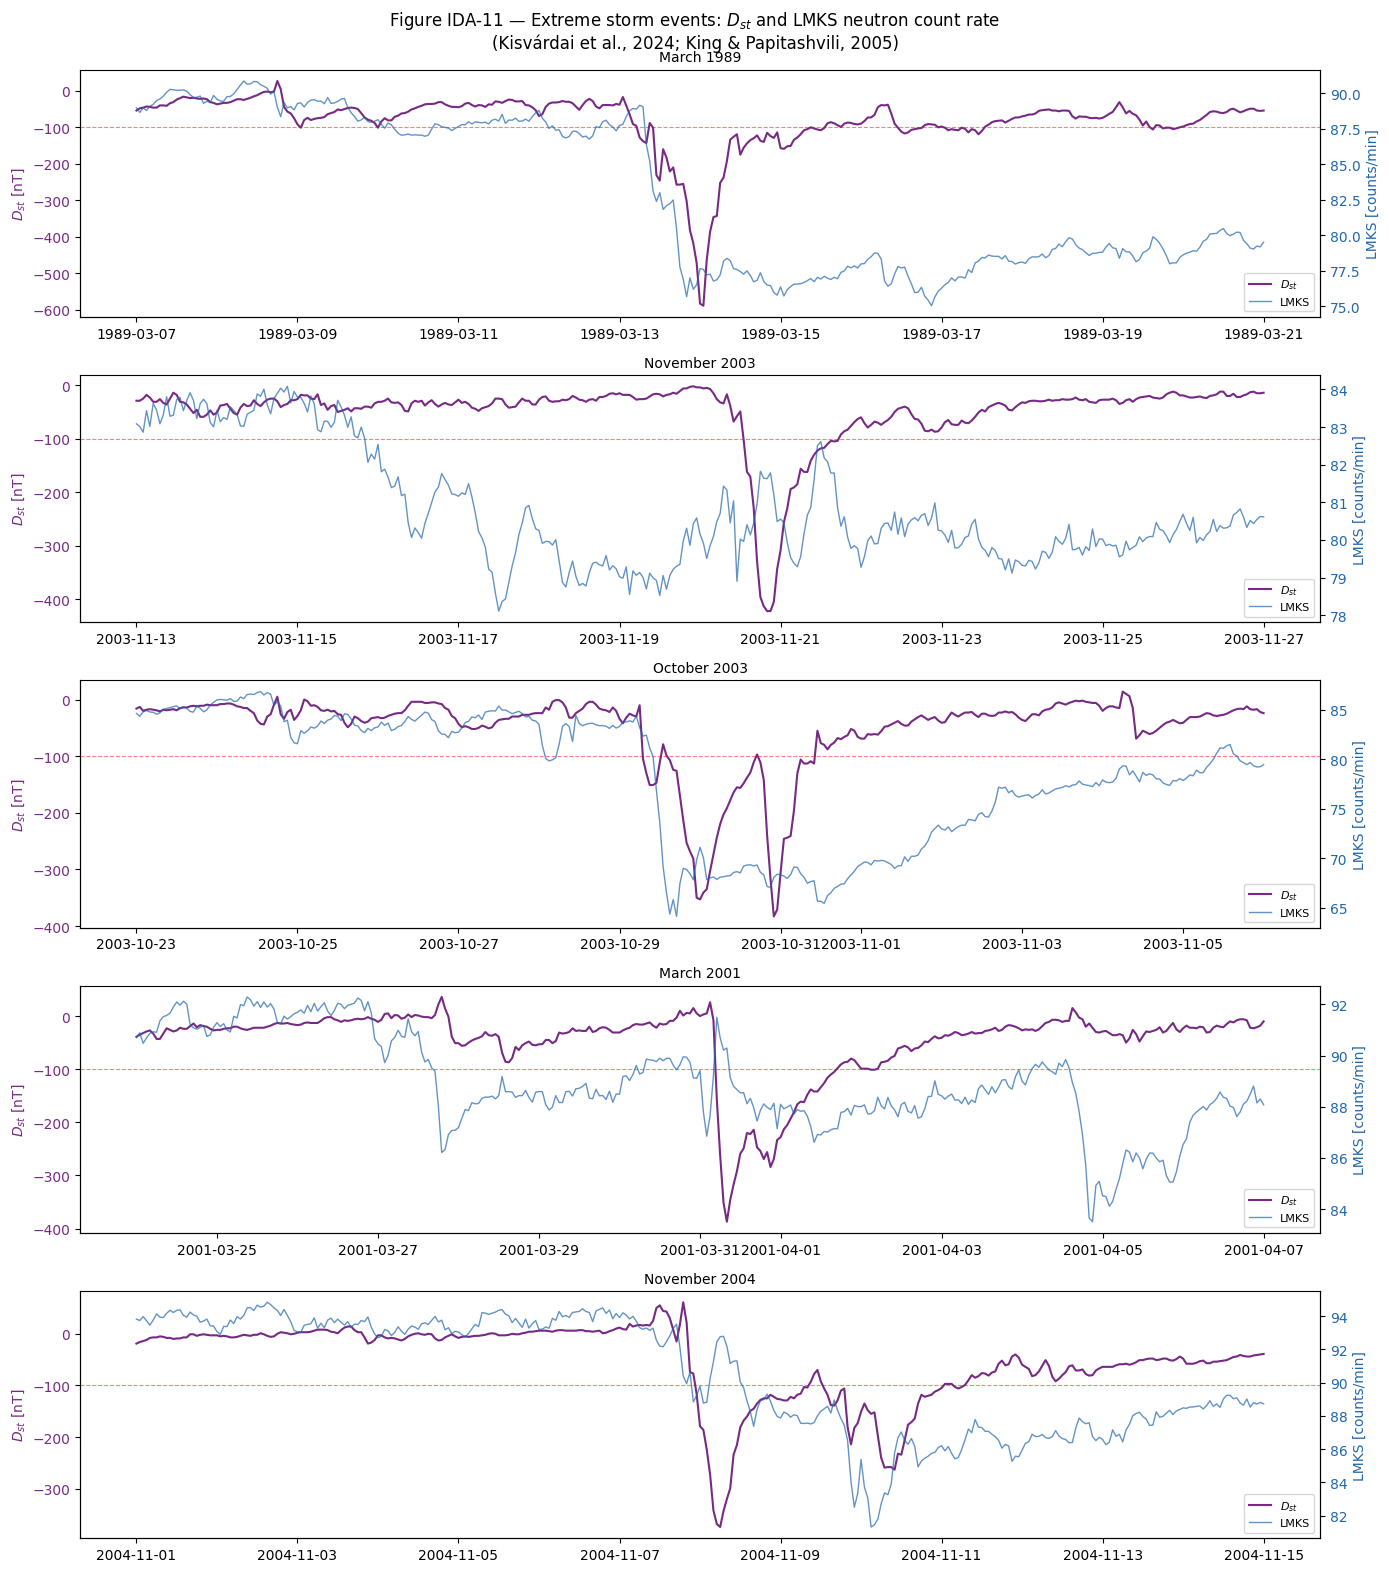

In [22]:
# ── IDA: Extreme storm events — Dst and LMKS profiles ────────────────────────
# Each panel shows a ±7 day window around the storm minimum.
# Dual Y-axis used deliberately to show temporal dynamics between Dst and LMKS.
# Note: the two axes have different scales and units.

events = [
    ('1989-03-14', 'March 1989'),
    ('2003-11-20', 'November 2003'),
    ('2003-10-30', 'October 2003'),
    ('2001-03-31', 'March 2001'),
    ('2004-11-08', 'November 2004'),
]

df_lmks_dt = df_lmks.copy()
df_lmks_dt['datetime'] = pd.to_datetime(df_lmks_dt['datetime'])

fig, axes = plt.subplots(len(events), 1, figsize=(14, 16), sharex=False)

for ax, (date_str, label) in zip(axes, events):
    center = pd.Timestamp(date_str)
    start  = center - pd.Timedelta(days=7)
    end    = center + pd.Timedelta(days=7)

    mask_dst   = (df_viz['datetime'] >= start) & (df_viz['datetime'] <= end)
    dst_event  = df_viz.loc[mask_dst, ['datetime', 'Dst-index, nT']]

    mask_lmks  = (df_lmks_dt['datetime'] >= start) & (df_lmks_dt['datetime'] <= end)
    lmks_event = df_lmks_dt.loc[mask_lmks, ['datetime', 'lmks_nm_counts']]

    ax_twin = ax.twinx()

    ax.plot(dst_event['datetime'], dst_event['Dst-index, nT'],
            color='#762a83', lw=1.5, label='$D_{st}$')
    ax.axhline(-100, color='red', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('$D_{st}$ [nT]', color='#762a83')
    ax.tick_params(axis='y', labelcolor='#762a83')

    ax_twin.plot(lmks_event['datetime'], lmks_event['lmks_nm_counts'],
                 color='#2166ac', lw=1.0, alpha=0.7, label='LMKS')
    ax_twin.set_ylabel('LMKS [counts/min]', color='#2166ac')
    ax_twin.tick_params(axis='y', labelcolor='#2166ac')

    ax.set_title(label, fontsize=10)
    ax.spines['top'].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

plt.suptitle('Figure IDA-11 — Extreme storm events: $D_{st}$ and LMKS neutron count rate\n(Kisvárdai et al., 2024; King & Papitashvili, 2005)', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida11_extreme_storms.png', dpi=150, bbox_inches='tight')
plt.show()



> **Note:** These plots use a dual Y-axis to show both $D_{st}$ and LMKS neutron count rate in the same panel. This layout is chosen deliberately to demonstrate the temporal dynamics between the two signals — the Forbush Decrease in LMKS and the storm main phase in $D_{st}$. The two axes have different scales and units and should not be compared in magnitude.

**Observations — Figure IDA-12:**

**March 1989** — the most intense storm in the record ($D_{st} = -589\ \text{nT}$). The LMKS neutron count rate shows a clear suppression beginning several days before the storm minimum — a textbook Forbush Decrease precursor `[KIS25]`. The recovery phase of both signals is visible after 14 March.

**November 2003** — the second most intense event ($D_{st} = -422\ \text{nT}$). A gradual Forbush Decrease is visible in LMKS starting around 17 November — approximately 3 days before the storm minimum on 20 November. The neutron count rate reaches its minimum close to the storm peak.

**October 2003** — the Halloween storm of 30 October ($D_{st} = -383\ \text{nT}$). A sharp Forbush Decrease is visible in LMKS around 28–29 October — consistent with the CME shock arrival at LMKS before the storm onset.

**March 2001** ($D_{st} = -387\ \text{nT}$). The LMKS signal shows a suppression before the storm minimum, though the pattern is less clean than in 1989 — consistent with a different CME geometry relative to the LMKS observer location `[KIS25]`.

**November 2004** ($D_{st} = -374\ \text{nT}$). A Forbush Decrease is visible in LMKS around 7–8 November, preceding the storm minimum by approximately 1–2 days.

Across all five events, the LMKS neutron count rate shows a suppression that precedes or coincides with the storm main phase — qualitatively consistent with the Forbush Decrease mechanism described in Section 2 `[KIS25]`. The lead time and amplitude vary between events, reflecting differences in CME geometry and propagation direction.
